Importart Librerías

In [ ]:
import pandas as pd
!pip install pyreadstat
import matplotlib.pyplot as plt
import re
import numpy as np
import shap
from google.colab import files
from glob import glob
from functools import reduce
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
import seaborn as sns
import joblib
import os

Importar archivos

In [ ]:

uploaded = files.upload()

Saving H_MHAS_d.dta to H_MHAS_d.dta


Leer Archivo

In [ ]:
df = pd.read_stata('H_MHAS_d.dta')
df_raw = df.copy()
[col for col in df.columns if 'tipent' in col]

# Identify all 'tipent' columns
tipent_cols = [c for c in df_raw.columns if c.startswith('tipent_') or c.startswith('tipent')]

# Keep only those for waves 3–6
tipent_cols = [c for c in tipent_cols if any(w in c for w in ['12', '15', '18', '21'])]

print("🧾 Interview columns detected:", tipent_cols)

# For each wave, count non-missing (valid) interview entries
wave_counts = {}
for col in tipent_cols:
    wave_num = ''.join(filter(str.isdigit, col))
    wave_label = {'3': 2012, '4': 2015, '5': 2018, '6': 2021}.get(wave_num, col)
    valid_mask = df_raw[col].notna() & (df_raw[col].astype(str).str.strip() != '')
    wave_counts[wave_label] = valid_mask.sum()

# Display results
print("\n📊 Total participants per wave (raw, before any filtering):")
for year, count in sorted(wave_counts.items()):
    print(f"Wave {year}: {count:,} participants")

🧾 Interview columns detected: ['tipent_12', 'tipent_15', 'tipent_18', 'tipent_21']

📊 Total participants per wave (raw, before any filtering):
Wave tipent_12: 15,723 participants
Wave tipent_15: 14,779 participants
Wave tipent_18: 17,114 participants
Wave tipent_21: 15,739 participants


Filtrado de Entrevistados (no 2001 y 2003, no entrevistados con menos de 2 entradas)

In [ ]:
# ====================================================
# 🧹 Filter participants: ≥2 valid waves (keep proxies)
# ====================================================

# --- 0️⃣ Define columns
id_col = 'unhhidnp'
tipent_cols = ['tipent_12', 'tipent_15', 'tipent_18', 'tipent_21']

# --- 1️⃣ Keep only needed columns
df_tipent = df[[id_col] + tipent_cols].copy()

# --- 2️⃣ Reshape from wide → long
df_long = df_tipent.melt(
    id_vars=id_col,
    value_vars=tipent_cols,
    var_name='wave_var',
    value_name='tipent'
)

# --- 3️⃣ Extract wave year (e.g., tipent_12 → 2012)
df_long['wave_year'] = df_long['wave_var'].str.extract(r'(\d+)$').astype(int) + 2000

# --- 4️⃣ Extract numeric code from interview string
df_long['tipent_code'] = (
    df_long['tipent']
    .astype(str)
    .str.extract(r'^(\d+)')[0]
    .astype(float)
)

# --- 5️⃣ Keep only valid interview codes (1–5)
df_long = df_long[df_long['tipent_code'].between(1, 5, inclusive='both')]

# --- 6️⃣ Keep only participants appearing in ≥2 valid waves
valid_ids = (
    df_long.groupby(id_col)['wave_year']
    .nunique()
    .reset_index()
    .query('wave_year >= 2')[id_col]
)

df_long = df_long[df_long[id_col].isin(valid_ids)]

# --- 7️⃣ Sort for readability
df_long = df_long.sort_values([id_col, 'wave_year']).reset_index(drop=True)

# --- 8️⃣ Basic stats
print("✅ Rows after filtering:", len(df_long))
print("✅ Unique participants:", df_long[id_col].nunique())
print("✅ Average valid waves per participant:",
      round(df_long.groupby(id_col)['wave_year'].nunique().mean(), 2))

print("\n🔍 Example rows:")
display(df_long.head(12))

# --- 9️⃣ Keep exact (ID, wave) pairs that are valid
valid_pairs = df_long[['unhhidnp', 'wave_year']].drop_duplicates()


# ====================================================
# 🧠 Merge extra information (age, birth info)
# ====================================================

# --- A️⃣ Static birth info
birth_vars = ['unhhidnp', 'rabyear', 'rabmonth']
df_birth = df[birth_vars].drop_duplicates(subset='unhhidnp')


# --- B️⃣ Age info: reshape from wide → long
wave_map = {3: 2012, 4: 2015, 5: 2018, 6: 2021}
age_cols = ['r3agey', 'r4agey', 'r5agey', 'r6agey']

df_age = df[['unhhidnp'] + age_cols].melt(
    id_vars='unhhidnp',
    var_name='wave_var',
    value_name='age'
)
df_age['wave_num'] = df_age['wave_var'].str.extract(r'(\d+)').astype(int)
df_age['wave_year'] = df_age['wave_num'].map(wave_map)


# --- C️⃣ Merge tipent + age + birth
df_long = (
    df_long
    .merge(df_age[['unhhidnp', 'wave_year', 'age']], on=['unhhidnp', 'wave_year'], how='left')
    .merge(df_birth, on='unhhidnp', how='left')
)

# --- D️⃣ Final clean-up
df_long = df_long[['unhhidnp', 'wave_var', 'tipent', 'wave_year', 'tipent_code', 'age', 'rabyear', 'rabmonth']]

# --- E️⃣ Verify results
print("\n✅ Final long-format dataset:")
print(df_long.head())
print(df_long.info())


# ====================================================
# 📊 Create per-wave tables (no duplicates!)
# ====================================================

df_2012 = df_long.query("wave_year == 2012").copy()
df_2015 = df_long.query("wave_year == 2015").copy()
df_2018 = df_long.query("wave_year == 2018").copy()
df_2021 = df_long.query("wave_year == 2021").copy()

print("\n📈 Participants per wave:")
print(df_long.groupby('wave_year')['unhhidnp'].nunique())

# Optional: quick sanity check for overlap
overlap_check = (
    df_long.groupby('unhhidnp')['wave_year'].nunique().value_counts().sort_index()
)
print("\n👥 Distribution of how many waves each person appears in:")
print(overlap_check)


✅ Rows after filtering: 60519
✅ Unique participants: 19202
✅ Average valid waves per participant: 3.15

🔍 Example rows:


,unhhidnp,wave_var,tipent,wave_year,tipent_code
0,120.0,tipent_12,"1.Direct, follow-up interview",2012,1.0
1,120.0,tipent_15,"1.Direct, follow-up interview",2015,1.0
2,120.0,tipent_18,"1.Direct, follow-up interview",2018,1.0
3,120.0,tipent_21,"1.Direct, follow-up interview",2021,1.0
4,210.0,tipent_12,"1.Direct, follow-up interview",2012,1.0
5,210.0,tipent_15,"1.Direct, follow-up interview",2015,1.0
6,210.0,tipent_18,"1.Direct, follow-up interview",2018,1.0
7,210.0,tipent_21,"1.Direct, follow-up interview",2021,1.0
8,220.0,tipent_12,"3.Proxy, follow-up interview",2012,3.0
9,220.0,tipent_15,"3.Proxy, follow-up interview",2015,3.0



✅ Final long-format dataset:
   unhhidnp   wave_var                         tipent  wave_year  tipent_code  \
0     120.0  tipent_12  1.Direct, follow-up interview       2012          1.0   
1     120.0  tipent_15  1.Direct, follow-up interview       2015          1.0   
2     120.0  tipent_18  1.Direct, follow-up interview       2018          1.0   
3     120.0  tipent_21  1.Direct, follow-up interview       2021          1.0   
4     210.0  tipent_12  1.Direct, follow-up interview       2012          1.0   

    age  rabyear  rabmonth  
0  62.0   1950.0       2.0  
1  65.0   1950.0       2.0  
2  68.0   1950.0       2.0  
3  71.0   1950.0       2.0  
4  81.0   1932.0       6.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60519 entries, 0 to 60518
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unhhidnp     60519 non-null  float32
 1   wave_var     60519 non-null  object 
 2   tipent       60519 non-null 

Filtrado de Entrevista por Proxy


🧾 PROXY INTERVIEW DIAGNOSTICS

📊 Proxy interview distribution per wave:


,n_proxy,n_total,pct_proxy
wave_year,,,
2012,922,13977,6.60
2015,897,14546,6.17
2018,1291,16584,7.78
2021,1231,15412,7.99



🧮 Total interviews (all waves): 60,519
🧮 Total proxies (all waves): 4,341 (7.17%)

✅ Filtering summary:
👥 Total participants before filtering: 19,202
👥 Total participants after filtering:  18,860
❌ Total participants removed (due to all waves being proxy): 342


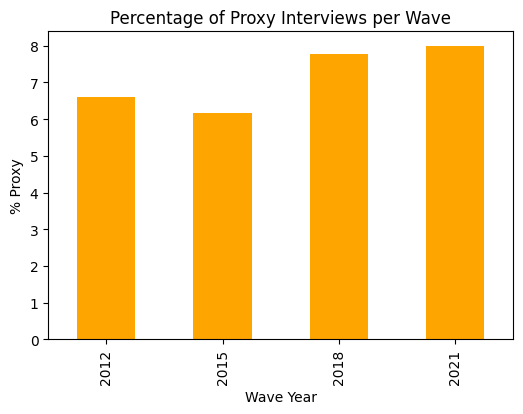

In [ ]:
# ====================================================
# 🧾 Diagnostics + Filtering: Proxy Interviews (string-based)
# ====================================================

print("\n==============================")
print("🧾 PROXY INTERVIEW DIAGNOSTICS")
print("==============================")

# --- 1️⃣ Define which labels count as proxy interviews
# Matches any entry that starts with '3.', '4.', or '5.' in the string
proxy_mask = df_long['tipent'].astype(str).str.startswith(('3.', '4.', '5.'))

# --- 2️⃣ Count total participants before filtering
total_before = df_long['unhhidnp'].nunique()

# --- 3️⃣ Count proxies per wave
proxy_summary = (
    df_long
    .assign(is_proxy=proxy_mask)
    .groupby('wave_year')['is_proxy']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'n_proxy', 'count': 'n_total'})
)
proxy_summary['pct_proxy'] = round(100 * proxy_summary['n_proxy'] / proxy_summary['n_total'], 2)

print("\n📊 Proxy interview distribution per wave:")
display(proxy_summary)

# --- 4️⃣ Overall proxy totals
total_proxies = proxy_summary['n_proxy'].sum()
total_interviews = proxy_summary['n_total'].sum()
pct_total_proxy = round(100 * total_proxies / total_interviews, 2)

print(f"\n🧮 Total interviews (all waves): {total_interviews:,}")
print(f"🧮 Total proxies (all waves): {total_proxies:,} ({pct_total_proxy}%)")

# --- 5️⃣ Filter them out from the full table (not per-wave)
df_no_proxy = df_long[~proxy_mask].copy()

# --- 6️⃣ Count participants after filtering
total_after = df_no_proxy['unhhidnp'].nunique()
removed_participants = total_before - total_after

print("\n✅ Filtering summary:")
print(f"👥 Total participants before filtering: {total_before:,}")
print(f"👥 Total participants after filtering:  {total_after:,}")
print(f"❌ Total participants removed (due to all waves being proxy): {removed_participants:,}")

# --- 7️⃣ Optional visual comparison
proxy_summary['pct_proxy'].plot(kind='bar', color='orange', figsize=(6,4))
plt.title("Percentage of Proxy Interviews per Wave")
plt.ylabel("% Proxy")
plt.xlabel("Wave Year")
plt.show()


📋 POST-FILTERING DIAGNOSTICS

✅ Participants per wave (after filtering proxies):


,unhhidnp
wave_year,
2012,13055
2015,13649
2018,15293
2021,14181



❌ Proxies removed summary:
Total proxies removed across all waves: 4,341
Percentage of all interviews that were proxies: 7.17%

📊 Proxies removed per wave:


,proxies_removed
wave_year,
2012,922
2015,897
2018,1291
2021,1231



📋 Participants per original per-wave table (before proxy filtering):
2012: 13,977
2015: 14,546
2018: 16,584
2021: 15,412

⚖️ Comparison Summary Table:


,Wave Year,Remaining After Filtering,Proxies Removed,Original Per-Wave Count,Net Difference
0,2012,13055,922,13977,922
1,2015,13649,897,14546,897
2,2018,15293,1291,16584,1291
3,2021,14181,1231,15412,1231


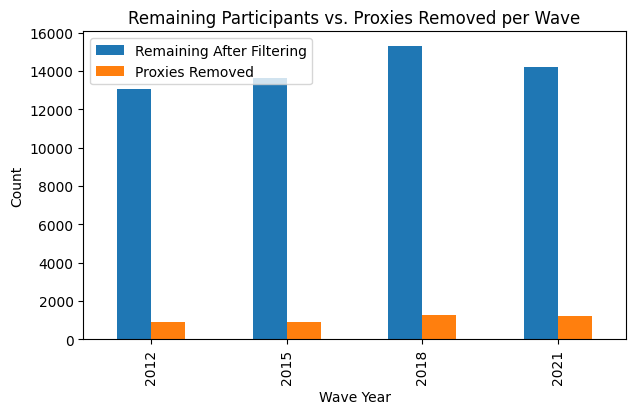

In [ ]:
# ====================================================
# 📋 Post-Filtering Diagnostic Summary
# ====================================================

print("\n==============================")
print("📋 POST-FILTERING DIAGNOSTICS")
print("==============================")

# --- 1️⃣ Participants per wave (after filtering proxies)
remaining_per_wave = (
    df_no_proxy
    .groupby('wave_year')['unhhidnp']
    .nunique()
    .sort_index()
)
print("\n✅ Participants per wave (after filtering proxies):")
display(remaining_per_wave)

# --- 2️⃣ Number of proxies removed (from previous step)
print("\n❌ Proxies removed summary:")
print(f"Total proxies removed across all waves: {total_proxies:,}")
print(f"Percentage of all interviews that were proxies: {pct_total_proxy}%")

# Optional: per-wave breakdown of proxies removed
print("\n📊 Proxies removed per wave:")
display(proxy_summary[['n_proxy']].rename(columns={'n_proxy': 'proxies_removed'}))

# --- 3️⃣ Participants per wave table (for comparison)
per_wave_counts_after = {
    2012: df_2012['unhhidnp'].nunique(),
    2015: df_2015['unhhidnp'].nunique(),
    2018: df_2018['unhhidnp'].nunique(),
    2021: df_2021['unhhidnp'].nunique(),
}
print("\n📋 Participants per original per-wave table (before proxy filtering):")
for year, count in per_wave_counts_after.items():
    print(f"{year}: {count:,}")

# --- 4️⃣ Combine all for side-by-side comparison
compare_post = pd.DataFrame({
    'Wave Year': remaining_per_wave.index,
    'Remaining After Filtering': remaining_per_wave.values,
    'Proxies Removed': proxy_summary['n_proxy'].values,
    'Original Per-Wave Count': [per_wave_counts_after.get(y, 0) for y in remaining_per_wave.index]
})
compare_post['Net Difference'] = compare_post['Original Per-Wave Count'] - compare_post['Remaining After Filtering']

print("\n⚖️ Comparison Summary Table:")
display(compare_post)

# --- 5️⃣ Quick visualization (optional)
compare_post.set_index('Wave Year')[['Remaining After Filtering', 'Proxies Removed']].plot(
    kind='bar', figsize=(7,4), title='Remaining Participants vs. Proxies Removed per Wave'
)
plt.ylabel('Count')
plt.show()

TESTING Uploading and reading Cognitivie Function Measures

In [ ]:
uploadedCFM = files.upload()

Saving CFM_2012.dta to CFM_2012.dta
Saving CFM_2018.dta to CFM_2018.dta
Saving CFM_2015.dta to CFM_2015.dta
Saving CFM_2021.dta to CFM_2021.dta


Subir y juntar archivos CFM

In [ ]:
print("\n==============================")
print("🧠 Merging CFM Cognitive Files into df_no_proxy")
print("==============================")

# ====================================================
# 1️⃣ Load and combine all CFM cognitive waves
# ====================================================

cfm_files = sorted(glob("/content/CFMs/*.dta"))

def get_wave_year(filename):
    """Extract wave year from filename like 'CFM_2012.dta'."""
    year_str = ''.join(filter(str.isdigit, filename))
    return int(year_str[-4:]) if len(year_str) >= 4 else None

cog_list = []

for file in cfm_files:
    year = get_wave_year(file)
    df_wave = pd.read_stata(file)

    # Lowercase all column names
    df_wave.columns = df_wave.columns.str.lower()

    # Find the cognitive status variable
    cog_vars = [c for c in df_wave.columns if f'cognitive_status_v01_{str(year)[2:]}' in c]

    if not cog_vars:
        print(f"⚠️ Wave {year}: No cognitive_status_v01 variable found.")
        continue

    print(f"✅ Wave {year}: Found {cog_vars}")

    # Keep only ID and cognitive variable
    df_wave = df_wave[['unhhidnp'] + cog_vars].copy()
    df_wave = df_wave.rename(columns={cog_vars[0]: f'cognitive_status_{year}'})

    cog_list.append(df_wave)

# Combine all waves horizontally (merge by ID)
df_cog = reduce(lambda left, right: pd.merge(left, right, on='unhhidnp', how='outer'), cog_list)
print(f"✅ Combined CFM cognitive data shape: {df_cog.shape}")

# ====================================================
# 2️⃣ Clean and harmonize IDs for merge
# ====================================================

def clean_main_id(x):
    """Standardize MHAS IDs (insert '0' before last two digits, zero-pad to 8)."""
    try:
        val = str(int(float(x)))
        if len(val) >= 2:
            val = val[:-2] + '0' + val[-2:]
        return val.zfill(8)
    except:
        return pd.NA

def clean_cfm_id(x):
    """Ensure CFM IDs are 8-digit strings."""
    if pd.isna(x):
        return pd.NA
    x = str(x).strip()
    x = ''.join(ch for ch in x if ch.isdigit())
    return x.zfill(8)

# Apply cleaning
df_no_proxy = df_no_proxy.copy()
df_no_proxy['merge_id'] = df_no_proxy['unhhidnp'].apply(clean_main_id)

df_cog = df_cog.copy()
df_cog['cfm_unhhidnp'] = df_cog['unhhidnp'].apply(clean_cfm_id)
df_cog = df_cog.drop(columns=['unhhidnp'])

print(f"✅ Cleaned IDs → df_no_proxy: {df_no_proxy['merge_id'].nunique():,} unique IDs")
print(f"✅ Cleaned IDs → df_cog: {df_cog['cfm_unhhidnp'].nunique():,} unique IDs")

# ====================================================
# 3️⃣ Merge CFM cognition into main dataset
# ====================================================

df_full = df_no_proxy.merge(df_cog, left_on='merge_id', right_on='cfm_unhhidnp', how='left')

print(f"\n✅ Merge completed successfully! Final shape: {df_full.shape}")

# ====================================================
# 4️⃣ Diagnostics
# ====================================================

matched = df_full['cfm_unhhidnp'].notna().sum()
match_pct = round(100 * matched / len(df_no_proxy), 2)
print(f"🔢 Matched CFM rows: {matched:,} of {len(df_no_proxy):,} ({match_pct}%)")

# Unique participants matched
unique_matched = df_full.loc[df_full['cfm_unhhidnp'].notna(), 'merge_id'].nunique()
print(f"🧠 Unique participants with cognition: {unique_matched:,} "
      f"({round(100 * unique_matched / df_no_proxy['merge_id'].nunique(), 2)}%)")

# Quick column check
cog_cols = [c for c in df_full.columns if c.startswith('cognitive_status_')]
print(f"\n📊 Cognitive columns merged: {cog_cols}")

# ====================================================
# 5️⃣ Final Cleanup (drop helper columns)
# ====================================================

cols_to_drop = ['wave_var', 'tipent_code',]
existing_to_drop = [c for c in cols_to_drop if c in df_full.columns]
if existing_to_drop:
    df_full = df_full.drop(columns=existing_to_drop)
    print(f"🧹 Dropped helper columns: {existing_to_drop}")
else:
    print("✅ No helper columns found to drop.")

# ====================================================
# 6️⃣ Merge Cognitive Columns into Single Variable
# ====================================================

print("\n==============================")
print("🧩 Collapsing cognitive_status columns into one unified variable")
print("==============================")

# Ensure wave_year is present and numeric
if 'wave_year' not in df_full.columns:
    print("⚠️ wave_year not found; attempting to infer from 'wave' column...")
    if 'wave' in df_full.columns:
        df_full['wave_year'] = df_full['wave'].astype(int)
    else:
        raise ValueError("❌ No 'wave_year' or 'wave' column found — cannot align cognition by year.")

def pick_cognitive_status(row):
    year = int(row['wave_year'])
    col_name = f'cognitive_status_{year}'
    return row[col_name] if col_name in row.index else np.nan

df_full['cognitive_status'] = df_full.apply(pick_cognitive_status, axis=1)

# Drop the original year-specific columns
df_full = df_full.drop(columns=cog_cols, errors='ignore')

print("✅ Unified cognitive_status column created successfully!")

# ====================================================
# 7️⃣ Clean and standardize cognitive_status values
# ====================================================

print("\n==============================")
print("🧼 Cleaning cognitive_status values...")
print("==============================")

# Convert to string and clean text patterns
df_full['cognitive_status'] = (
    df_full['cognitive_status']
    .astype(str)
    .str.strip()
    .replace({
        r'^0.*Normal$': '0.0',
        r'^0.*$': '0.0',
        r'^1.*Normal with Impairment.*$': '1.0',
        r'^1.*$': '1.0',
        r'^2.*CIND.*$': '2.0',
        r'^2.*$': '2.0',
        r'^3.*Dementia.*$': '3.0',
        r'^3.*$': '3.0',
        'nan': np.nan,
        'NaN': np.nan,
        'None': np.nan
    }, regex=True)
)

# Convert final cleaned values to float
df_full['cognitive_status'] = pd.to_numeric(df_full['cognitive_status'], errors='coerce')

# Quick check
print("✅ Cleaned cognitive_status unique values:")
print(df_full['cognitive_status'].unique())

print("\n✅ Final unified and cleaned dataset ready!")
display(df_full.head(15))



🧠 Merging CFM Cognitive Files into df_no_proxy
✅ Wave 2012: Found ['cognitive_status_v01_12']
✅ Wave 2015: Found ['cognitive_status_v01_15']
✅ Wave 2018: Found ['cognitive_status_v01_18']
✅ Wave 2021: Found ['cognitive_status_v01_21']
✅ Combined CFM cognitive data shape: (22038, 5)
✅ Cleaned IDs → df_no_proxy: 18,860 unique IDs
✅ Cleaned IDs → df_cog: 22,038 unique IDs

✅ Merge completed successfully! Final shape: (56178, 14)
🔢 Matched CFM rows: 56,178 of 56,178 (100.0%)
🧠 Unique participants with cognition: 18,860 (100.0%)

📊 Cognitive columns merged: ['cognitive_status_2012', 'cognitive_status_2015', 'cognitive_status_2018', 'cognitive_status_2021']
🧹 Dropped helper columns: ['wave_var', 'tipent_code']

🧩 Collapsing cognitive_status columns into one unified variable
✅ Unified cognitive_status column created successfully!

🧼 Cleaning cognitive_status values...
✅ Cleaned cognitive_status unique values:
[ 0.  2.  1.  3. nan]

✅ Final unified and cleaned dataset ready!


,unhhidnp,tipent,wave_year,age,rabyear,rabmonth,merge_id,cfm_unhhidnp,cognitive_status
0,120.0,"1.Direct, follow-up interview",2012,62.0,1950.0,2.0,00001020,00001020,0.0
1,120.0,"1.Direct, follow-up interview",2015,65.0,1950.0,2.0,00001020,00001020,0.0
2,120.0,"1.Direct, follow-up interview",2018,68.0,1950.0,2.0,00001020,00001020,0.0
3,120.0,"1.Direct, follow-up interview",2021,71.0,1950.0,2.0,00001020,00001020,0.0
4,210.0,"1.Direct, follow-up interview",2012,81.0,1932.0,6.0,00002010,00002010,2.0
5,210.0,"1.Direct, follow-up interview",2015,83.0,1932.0,6.0,00002010,00002010,0.0
6,210.0,"1.Direct, follow-up interview",2018,86.0,1932.0,6.0,00002010,00002010,0.0
7,210.0,"1.Direct, follow-up interview",2021,89.0,1932.0,6.0,00002010,00002010,1.0
8,310.0,"1.Direct, follow-up interview",2012,62.0,1950.0,6.0,00003010,00003010,0.0
9,310.0,"1.Direct, follow-up interview",2015,65.0,1950.0,6.0,00003010,00003010,0.0


In [ ]:
# ====================================================
# ✅ Corrected merge diagnostics (participant-level, using unhhidnp)
# ====================================================

print("\n==============================")
print("🔍 MERGE DIAGNOSTICS — PARTICIPANT-LEVEL")
print("==============================")

# 1️⃣ Participant universe (after proxy filtering)
n_participants = df_no_proxy['unhhidnp'].nunique()
print(f"👥 Participants after proxy filtering (unique): {n_participants:,}")

# 2️⃣ Row-level vs participant-level matches (based on unified cognitive_status)
row_matches = df_full['cognitive_status'].notna().sum()
unique_matches = df_full.loc[df_full['cognitive_status'].notna(), 'unhhidnp'].nunique()

print(f"🔢 Row-level matches (person×wave rows with a CFM match): {row_matches:,}")
print(f"🧠 Participant-level matches (unique unhhidnp with a CFM match): {unique_matches:,} "
      f"({unique_matches / n_participants:.2%} of participants)")

# 3️⃣ Per-wave: unique participants AFTER merge (this will align with your second diagnostic)
per_wave_after_merge = (
    df_full.loc[df_full['cognitive_status'].notna()]
           .groupby('wave_year')['unhhidnp']
           .nunique()
           .sort_index()
)

# For comparison: per-wave participants in the filtered master (no cognition requirement)
per_wave_in_filtered = (
    df_no_proxy.groupby('wave_year')['unhhidnp']
               .nunique()
               .sort_index()
)

print("\n📋 Per-wave unique participants in df_no_proxy (post-proxy filter):")
print(per_wave_in_filtered)

# Side-by-side comparison
compare_waves = (
    per_wave_in_filtered.to_frame('participants_filtered')
    .assign(participants_with_cog=per_wave_after_merge)
    .fillna(0)
    .astype(int)
)
compare_waves['difference'] = (
    compare_waves['participants_filtered'] - compare_waves['participants_with_cog']
)
compare_waves['pct_with_data'] = round(
    100 * compare_waves['participants_with_cog'] / compare_waves['participants_filtered'], 2
)
compare_waves['pct_missing'] = 100 - compare_waves['pct_with_data']

print("\n⚖️ Per-wave comparison (filtered vs. with cognition):")
display(compare_waves)

# 4️⃣ Sanity: verify no proxies reappeared after merge
proxy_mask_full = df_full['tipent'].astype(str).str.startswith(('3.', '4.', '5.'))
n_proxy_rows_full = proxy_mask_full.sum()
n_proxy_participants_full = df_full.loc[proxy_mask_full, 'unhhidnp'].nunique()

print("\n🧪 Proxy sanity check in df_full:")
print(f" - Proxy rows present? {n_proxy_rows_full:,}")
print(f" - Proxy participants present? {n_proxy_participants_full:,}")

if n_proxy_rows_full == 0 and n_proxy_participants_full == 0:
    print("✅ OK: No proxy interviews in the merged table.")
else:
    print("⚠️ Unexpected proxies detected in df_full. Make sure you built df_full from df_no_proxy and not from any unfiltered base.")


# ====================================================
# 🧠 Cognitive Status Coverage Diagnostic (NaN = missing)
# ====================================================

print("\n==============================")
print("🧠 Cognitive Status Coverage (Post-Merge, NaN = Missing)")
print("==============================")

# Use the unified cognitive_status column
if 'cognitive_status' not in df_full.columns:
    raise ValueError("❌ 'cognitive_status' column not found. Ensure wave collapse ran successfully.")

coverage_rows = []
for wave, sub in df_full.groupby('wave_year'):
    total_participants = sub['unhhidnp'].nunique()
    with_cog = sub.loc[sub['cognitive_status'].notna(), 'unhhidnp'].nunique()
    without_cog = total_participants - with_cog
    coverage_rows.append({
        'wave_year': wave,
        'total_participants': total_participants,
        'with_cognitive_status': with_cog,
        'without_cognitive_status': without_cog,
        'pct_with_data': round(100 * with_cog / total_participants, 2),
        'pct_missing': round(100 * without_cog / total_participants, 2)
    })

df_cog_merge_diag = pd.DataFrame(coverage_rows).sort_values('wave_year')
print("\n📊 Cognitive Data Completeness per Wave:")
display(df_cog_merge_diag)

# ====================================================
# 👀 Preview first rows
# ====================================================
print("\n👀 Preview of the first 25 rows in df_full (merged dataset):")
pd.set_option('display.max_columns', None)
display(df_full.head(25))





🔍 MERGE DIAGNOSTICS — PARTICIPANT-LEVEL
👥 Participants after proxy filtering (unique): 18,860
🔢 Row-level matches (person×wave rows with a CFM match): 55,194
🧠 Participant-level matches (unique unhhidnp with a CFM match): 18,776 (99.55% of participants)

📋 Per-wave unique participants in df_no_proxy (post-proxy filter):
wave_year
2012    13055
2015    13649
2018    15293
2021    14181
Name: unhhidnp, dtype: int64

⚖️ Per-wave comparison (filtered vs. with cognition):


,participants_filtered,participants_with_cog,difference,pct_with_data,pct_missing
wave_year,,,,,
2012,13055,12703,352,97.30,2.70
2015,13649,13416,233,98.29,1.71
2018,15293,15055,238,98.44,1.56
2021,14181,14020,161,98.86,1.14



🧪 Proxy sanity check in df_full:
 - Proxy rows present? 0
 - Proxy participants present? 0
✅ OK: No proxy interviews in the merged table.

🧠 Cognitive Status Coverage (Post-Merge, NaN = Missing)

📊 Cognitive Data Completeness per Wave:


,wave_year,total_participants,with_cognitive_status,without_cognitive_status,pct_with_data,pct_missing
0,2012,13055,12703,352,97.30,2.70
1,2015,13649,13416,233,98.29,1.71
2,2018,15293,15055,238,98.44,1.56
3,2021,14181,14020,161,98.86,1.14



👀 Preview of the first 25 rows in df_full (merged dataset):


,unhhidnp,tipent,wave_year,age,rabyear,rabmonth,merge_id,cfm_unhhidnp,cognitive_status
0,120.0,"1.Direct, follow-up interview",2012,62.0,1950.0,2.0,00001020,00001020,0.0
1,120.0,"1.Direct, follow-up interview",2015,65.0,1950.0,2.0,00001020,00001020,0.0
2,120.0,"1.Direct, follow-up interview",2018,68.0,1950.0,2.0,00001020,00001020,0.0
3,120.0,"1.Direct, follow-up interview",2021,71.0,1950.0,2.0,00001020,00001020,0.0
4,210.0,"1.Direct, follow-up interview",2012,81.0,1932.0,6.0,00002010,00002010,2.0
5,210.0,"1.Direct, follow-up interview",2015,83.0,1932.0,6.0,00002010,00002010,0.0
6,210.0,"1.Direct, follow-up interview",2018,86.0,1932.0,6.0,00002010,00002010,0.0
7,210.0,"1.Direct, follow-up interview",2021,89.0,1932.0,6.0,00002010,00002010,1.0
8,310.0,"1.Direct, follow-up interview",2012,62.0,1950.0,6.0,00003010,00003010,0.0
9,310.0,"1.Direct, follow-up interview",2015,65.0,1950.0,6.0,00003010,00003010,0.0



🧠 Cognitive Status Distribution (unique participants per wave)
👥 Total unique participants: 18,860
🧠 With any cognitive status: 18,776 (99.55%)
❌ Missing cognitive data: 84 (0.45%)

📊 OVERALL Cognitive Status Distribution:


,cognitive_status,n_participants,pct_within_all
0,0.0,17104,63.95
1,1.0,3327,12.44
2,2.0,5108,19.10
3,3.0,1205,4.51



📊 PER-WAVE Cognitive Status Distribution:


,wave_year,cognitive_status,n_participants,pct_within_wave,total_participants,with_cognitive_status,without_cognitive_status,pct_with_data,pct_missing
0,2012,0.0,9823,77.33,13055,12703,352,97.30,2.70
1,2012,1.0,905,7.12,13055,12703,352,97.30,2.70
2,2012,2.0,1710,13.46,13055,12703,352,97.30,2.70
3,2012,3.0,265,2.09,13055,12703,352,97.30,2.70
4,2015,0.0,9856,73.46,13649,13416,233,98.29,1.71
5,2015,1.0,1280,9.54,13649,13416,233,98.29,1.71
6,2015,2.0,1814,13.52,13649,13416,233,98.29,1.71
7,2015,3.0,466,3.47,13649,13416,233,98.29,1.71
8,2018,0.0,11665,77.48,15293,15055,238,98.44,1.56
9,2018,1.0,1070,7.11,15293,15055,238,98.44,1.56


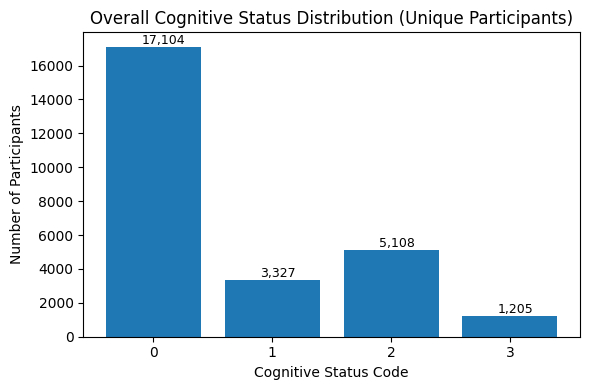

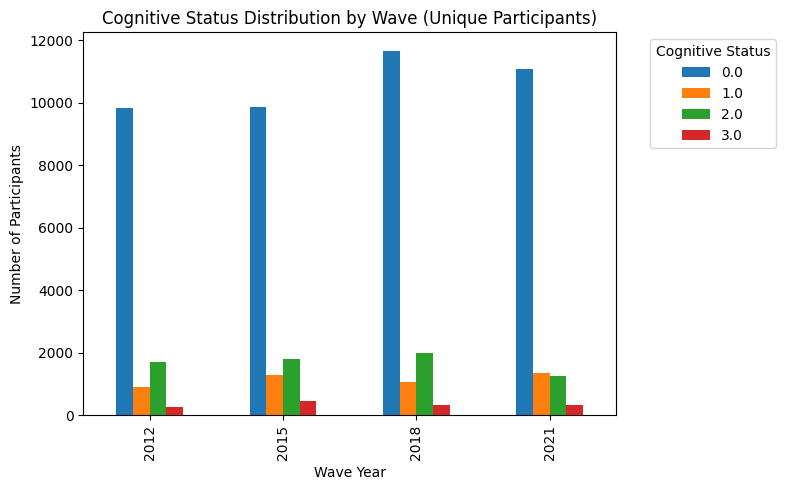

In [ ]:
# ====================================================
# 🧠 Cognitive Status Distribution — Deduplicated
# ====================================================

print("\n==============================")
print("🧠 Cognitive Status Distribution (unique participants per wave)")
print("==============================")

# 1️⃣ Deduplicate to avoid overcounting
df_cog_unique = (
    df_full
    .drop_duplicates(subset=['merge_id', 'wave_year', 'cognitive_status'])
    .copy()
)

# Ensure numeric type
df_cog_unique['cognitive_status'] = pd.to_numeric(df_cog_unique['cognitive_status'], errors='coerce')

# 2️⃣ Overall participant-level counts
total_participants = df_cog_unique['merge_id'].nunique()
with_cog = df_cog_unique.loc[df_cog_unique['cognitive_status'].notna(), 'merge_id'].nunique()
missing = total_participants - with_cog
pct_with = round(100 * with_cog / total_participants, 2)
pct_missing = round(100 * missing / total_participants, 2)

print(f"👥 Total unique participants: {total_participants:,}")
print(f"🧠 With any cognitive status: {with_cog:,} ({pct_with}%)")
print(f"❌ Missing cognitive data: {missing:,} ({pct_missing}%)")

# 3️⃣ Overall distribution (unique participants per cognitive class)
overall_counts = (
    df_cog_unique.loc[df_cog_unique['cognitive_status'].notna()]
    .drop_duplicates(subset=['merge_id', 'cognitive_status'])
    .groupby('cognitive_status')['merge_id']
    .nunique()
    .reset_index(name='n_participants')
)
overall_counts['pct_within_all'] = round(
    100 * overall_counts['n_participants'] / overall_counts['n_participants'].sum(), 2
)

print("\n📊 OVERALL Cognitive Status Distribution:")
display(overall_counts)

# 4️⃣ Per-wave summary (unique participants × wave)
perwave_rows = []
for year, sub in df_cog_unique.groupby('wave_year'):
    total_wave = sub['merge_id'].nunique()
    with_cog_wave = sub.loc[sub['cognitive_status'].notna(), 'merge_id'].nunique()
    missing_wave = total_wave - with_cog_wave
    pct_with_wave = round(100 * with_cog_wave / total_wave, 2)
    pct_missing_wave = round(100 * missing_wave / total_wave, 2)

    for val in [0.0, 1.0, 2.0, 3.0]:
        n = sub.loc[sub['cognitive_status'] == val, 'merge_id'].nunique()
        p = round(100 * n / with_cog_wave, 2) if with_cog_wave > 0 else 0
        perwave_rows.append({
            'wave_year': year,
            'cognitive_status': val,
            'n_participants': n,
            'pct_within_wave': p,
            'total_participants': total_wave,
            'with_cognitive_status': with_cog_wave,
            'without_cognitive_status': missing_wave,
            'pct_with_data': pct_with_wave,
            'pct_missing': pct_missing_wave
        })

df_cog_perwave = pd.DataFrame(perwave_rows).sort_values(['wave_year', 'cognitive_status'])

print("\n📊 PER-WAVE Cognitive Status Distribution:")
display(df_cog_perwave)

# ====================================================
# 📉 Visualization — Unique Counts
# ====================================================

import matplotlib.pyplot as plt

# Overall distribution
plt.figure(figsize=(6,4))
plt.bar(overall_counts['cognitive_status'], overall_counts['n_participants'])
plt.title("Overall Cognitive Status Distribution (Unique Participants)")
plt.xlabel("Cognitive Status Code")
plt.ylabel("Number of Participants")
plt.xticks([0,1,2,3])
for i, v in enumerate(overall_counts['n_participants']):
    plt.text(i - 0.1, v + (0.01 * max(overall_counts['n_participants'])), f"{v:,}", fontsize=9)
plt.tight_layout()
plt.show()

# Per-wave grouped bar chart
pivot = (
    df_cog_perwave.pivot(index='wave_year', columns='cognitive_status', values='n_participants')
    .fillna(0)
    .astype(int)
)
pivot.plot(kind='bar', figsize=(8,5))
plt.title("Cognitive Status Distribution by Wave (Unique Participants)")
plt.xlabel("Wave Year")
plt.ylabel("Number of Participants")
plt.legend(title="Cognitive Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Define variable groups

In [ ]:
# ====================================================
# 🧩 Merge Risk Factor Variables into Cognitive Dataset
# ====================================================

print("\n==============================")
print("🧠 Merging Risk Factors into Cognitive Dataset (using df_raw)")
print("==============================")

# --- 1️⃣ Wave mapping and ID cleaning ---
wave_map = {3: 2012, 4: 2015, 5: 2018, 6: 2021}

def clean_main_id(x):
    """Convert numeric IDs into standardized 8-digit strings."""
    try:
        val = str(int(float(x)))
        if len(val) >= 2:
            val = val[:-2] + '0' + val[-2:]
        return val.zfill(8)
    except:
        return pd.NA

# Apply cleaning
df_raw = df_raw.copy()
df_raw['merge_id'] = df_raw['unhhidnp'].apply(clean_main_id)

df_full = df_full.copy()
df_full['merge_id'] = df_full['unhhidnp'].apply(clean_main_id)
df_full['wave_year'] = df_full['wave_year'].astype(int)

# --- 2️⃣ Define risk factor groups (unchanged) ---
risk_factor_groups = {
    'escolaridad': ['raedyrs', 'raliterate', 'ranumerate'],
    'perdida_audicion': ['rWhearing', 'rWhearaid'],
    'colesterol': ['rWcholst'],
    'lesion_cerebral': ['rWstroke', 'rWrxstrok', 'rWrecstrok'],
    'actividad_fisica': ['rWvigact'],
    'diabetes': ['rWdiabe', 'rWrxdiab'],
    'tabaquismo': ['rWsmokev', 'rWsmoken', 'rWsmokef', 'rWsmokefm', 'rWstrtsmok', 'rWquitsmok'],
    'hipertension': ['rWhibpe', 'rWrxhibp'],
    'obesidad': ['rWbmi', 'rWobese'],
    'alcohol': ['rWdrink', 'rWdrinkd', 'rWdrinkn', 'rWdrinkb', 'rWbinged', 'rWcage'],
    'aislamiento_social': ['rWdrinkcr', 'hWrural_m', 'rWrfcntpmx_m', 'rWcesd_m'],
    'contaminacion_aire': ['hWrural', 'hWrural_m'],
    'vision': ['rWsight', 'rWglasses'],
    'estres': ['rWunemp', 'rWjhoursd', 'hWchdeathe', 'rWcconc_m'],
    'locus_control': ['rWlsatsc3m', 'rWsatlifez'],
    'uso_tiempo': ['rWsocact_m', 'rWwork', 'rWslfemp'],
    'caidas': ['rWfall', 'rWfallnum', 'rWfallinj'],
    'hospitalizacion': ['rWhosp1y', 'rWhspnit1y']
}

# ====================================================
# 🧩 Build Expanded + Long-Format Risk-Factor Table (Corrected hW logic)
# ====================================================

waves = [3, 4, 5, 6]
expanded_groups = {}

for group, base_vars in risk_factor_groups.items():
    expanded_vars = []

    for var in base_vars:
        # Wave-dependent household vars (hW...) → expand just like rW...
        if "hW" in var or "rW" in var:
            for w in waves:
                candidate = var.replace("W", str(w))
                if candidate in df_raw.columns:
                    expanded_vars.append(candidate)

        # Truly static respondent-level vars (raedyrs, raliterate, etc.)
        else:
            if var in df_raw.columns:
                expanded_vars.append(var)

    expanded_groups[group] = sorted(set(expanded_vars))

# Flatten and verify
all_vars = sorted(set(v for vs in expanded_groups.values() for v in vs))
available_vars = [v for v in all_vars if v in df_raw.columns]
print(f"✅ Found {len(available_vars)} of {len(all_vars)} possible variables in df_raw.")

missing_vars = [v for v in all_vars if v not in df_raw.columns]
if missing_vars:
    print(f"⚠️ Missing {len(missing_vars)} variables (examples): {missing_vars[:10]}")

# ====================================================
# 🧱 Build long-format risk-factor DataFrame
# ====================================================

risk_frames = []

for wave_num, year in wave_map.items():
    wave_cols = [v for v in available_vars if f"{wave_num}" in v]
    static_cols = [v for v in available_vars
                   if not any(str(w) in v for w in waves)]  # only truly static ones (like raedyrs)

    subset = df_raw[['merge_id'] + wave_cols + static_cols].copy()
    subset['wave_year'] = year

    # Harmonize naming
    rename_map = {v: v.replace(str(wave_num), "W") for v in wave_cols}
    subset = subset.rename(columns=rename_map)

    risk_frames.append(subset)

risk_long = pd.concat(risk_frames, ignore_index=True)
print(f"✅ Built long-format risk-factor table. Shape: {risk_long.shape}")


# --- 6️⃣ Merge with df_full (main cognitive dataset) ---
df_merged = df_full.merge(risk_long, on=['merge_id', 'wave_year'], how='left')

print(f"\n✅ Final merged shape: {df_merged.shape}")
print(f"✅ Added {risk_long.shape[1] - 2} risk factor variables (excluding merge_id & wave_year).")

# --- 7️⃣ Quick participant check ---
print("\n👥 Participants per wave after merge:")
display(df_merged.groupby('wave_year')['merge_id'].nunique())

# --- 8️⃣ Final dataset preview ---
pd.set_option('display.max_columns', 100)
display(df_merged.head(50))


🧠 Merging Risk Factors into Cognitive Dataset (using df_raw)
✅ Found 176 of 176 possible variables in df_raw.
✅ Built long-format risk-factor table. Shape: (108636, 54)

✅ Final merged shape: (56178, 61)
✅ Added 52 risk factor variables (excluding merge_id & wave_year).

👥 Participants per wave after merge:


,merge_id
wave_year,
2012,13055
2015,13649
2018,15293
2021,14181


,unhhidnp,tipent,wave_year,age,rabyear,rabmonth,merge_id,cfm_unhhidnp,cognitive_status,hWchdeathe,hWrural,hWrural_m,rWbinged,rWbmi,rWcage,rWcesd_m,rWcholst,rWdiabe,rWdrink,rWdrinkb,rWdrinkcr,rWdrinkd,rWdrinkn,rWfall,rWfallinj,rWfallnum,rWglasses,rWhearaid,rWhearing,rWhibpe,rWhosp1y,rWhspnit1y,rWlsatscWm,rWobese,rWquitsmok,rWrecstrok,rWrfcntpmx_m,rWrxdiab,rWrxhibp,rWrxstrok,rWsatlifez,rWsight,rWslfemp,rWsmokef,rWsmokefm,rWsmoken,rWsmokev,rWsocact_m,rWstroke,rWstrtsmok,rWunemp,rWvigact,rWwork,r4lsatscWm,r5lsatscWm,r6lsatscWm,raedyrs,raliterate,ranumerate,rWlsatsc3m,rWcconc_m
0,120.0,"1.Direct, follow-up interview",2012,62.0,1950.0,2.0,00001020,00001020,0.0,1.Yes,0.urban,1.Urban,0.0,NaN,NaN,0.0,0.No,0.no,0.no,0.no,NaN,0.0,0.0,1.yes,NaN,1.0,1.yes,0.no,NaN,0.no,0.No,0.0,0.0,NaN,NaN,NaN,9.Never,0.no,0.no,0.no,1.510731,3.Good,NaN,0.0,0.0,0.No,0.No,9.Never,0.no,NaN,NaN,0.No,0.Not working for pay,0.0,0.0,0.0,3.0,1.Yes,1.Yes,NaN,NaN
1,120.0,"1.Direct, follow-up interview",2015,65.0,1950.0,2.0,00001020,00001020,0.0,1.Yes,0.urban,1.Urban,0.0,20.000000,NaN,6.0,0.No,0.no,0.no,0.no,NaN,0.0,0.0,0.no,0.no,0.0,0.no,0.no,3.Good,0.no,0.No,0.0,NaN,0.No,NaN,NaN,3.2 or 3 times a week,0.no,0.no,0.no,-0.387025,3.Good,NaN,0.0,0.0,0.No,0.No,9.Never,0.no,NaN,NaN,0.No,0.Not working for pay,NaN,NaN,NaN,3.0,1.Yes,1.Yes,0.0,NaN
2,120.0,"1.Direct, follow-up interview",2018,68.0,1950.0,2.0,00001020,00001020,0.0,1.Yes,0.urban,1.Urban,0.0,NaN,NaN,3.0,1.Yes,0.no,0.no,0.no,NaN,0.0,0.0,0.no,0.no,0.0,1.yes,0.no,3.Good,0.no,0.No,0.0,NaN,NaN,NaN,NaN,1.Almost every day,0.no,0.no,0.no,-0.393398,3.Good,NaN,0.0,0.0,0.No,0.No,9.Never,0.no,NaN,NaN,0.No,0.Not working for pay,NaN,NaN,NaN,3.0,1.Yes,1.Yes,0.0,NaN
3,120.0,"1.Direct, follow-up interview",2021,71.0,1950.0,2.0,00001020,00001020,0.0,1.Yes,0.urban,1.Urban,0.0,NaN,NaN,2.0,0.No,0.no,0.no,0.no,NaN,0.0,0.0,0.no,0.no,0.0,1.yes,0.no,3.Good,0.no,0.No,0.0,NaN,NaN,NaN,NaN,9.Never,0.no,0.no,0.no,-0.337781,3.Good,NaN,0.0,0.0,0.No,0.No,5.4 or more times a month,0.no,NaN,NaN,0.No,0.Not working for pay,NaN,NaN,NaN,3.0,1.Yes,1.Yes,0.0,3.Some
4,210.0,"1.Direct, follow-up interview",2012,81.0,1932.0,6.0,00002010,00002010,2.0,1.Yes,0.urban,1.Urban,0.0,NaN,NaN,8.0,1.Yes,0.no,0.no,0.no,NaN,0.0,0.0,0.no,0.no,0.0,1.yes,0.no,NaN,0.no,0.No,0.0,0.0,NaN,60.0,NaN,9.Never,0.no,0.no,0.no,-0.397267,5.Poor,NaN,0.0,6.0,0.No,1.Yes,9.Never,0.no,14.0,NaN,1.Yes,0.Not working for pay,0.0,0.0,0.0,0.0,1.Yes,1.Yes,NaN,NaN
5,210.0,"1.Direct, follow-up interview",2015,83.0,1932.0,6.0,00002010,00002010,0.0,1.Yes,0.urban,1.Urban,0.0,26.709404,NaN,7.0,1.Yes,0.no,0.no,0.no,NaN,0.0,0.0,1.yes,NaN,2.0,1.yes,0.no,3.Good,0.no,0.No,0.0,NaN,0.No,60.0,NaN,1.Almost every day,0.no,0.no,0.no,-0.387025,3.Good,NaN,0.0,0.0,0.No,0.No,1.Almost every day,0.no,14.0,NaN,1.Yes,0.Not working for pay,NaN,NaN,NaN,0.0,1.Yes,1.Yes,0.0,NaN
6,210.0,"1.Direct, follow-up interview",2018,86.0,1932.0,6.0,00002010,00002010,0.0,1.Yes,0.urban,1.Urban,0.0,NaN,NaN,1.0,1.Yes,1.yes,0.no,0.no,NaN,0.0,0.0,0.no,0.no,0.0,0.no,0.no,3.Good,1.yes,1.Yes,1.0,NaN,NaN,60.0,NaN,4.Once a week,1.yes,1.yes,0.no,-0.393398,3.Good,NaN,0.0,0.0,0.No,0.No,3.2 or 3 times a week,0.no,14.0,NaN,0.No,0.Not working for pay,NaN,NaN,NaN,0.0,1.Yes,1.Yes,0.0,NaN
7,210.0,"1.Direct, follow-up interview",2021,89.0,1932.0,6.0,00002010,00002010,1.0,1.Yes,0.urban,1.Urban,0.0,NaN,NaN,6.0,1.Yes,1.yes,1.yes,0.no,NaN,2.0,1.0,1.yes,NaN,2.0,1.yes,0.no,3.Good,1.yes,0.No,0.0,NaN,NaN,29.0,NaN,3.2 or 3 times a week,0.no,1.yes,0.no,-0.337781,4.Fair,NaN,0.0,10.0,0.No,1.Yes,9.Never,0.no,14.0,NaN,1.Yes,0.Not working for pay,NaN,NaN,NaN,0.0,1.Yes,1.Yes,0.0,3.Some
8,310.0,"1.Direct, follow-up interview",2012,62.0,1950.0,6.0,00003010,00003010,0.0,1.Yes,0.urban,1.Urban,0.0,28.400547,NaN,2.0,1.Yes,1.yes,0.no,0.no,NaN,0.0,0.0,0.no,0.no,0.0,1.yes,0.no,NaN,0.no,0.No,0.0,0.0,0.No,36.0,NaN,9.Never,1.yes,0.no,0.no,-0.397267,3.Good,0.Not self-employed,0.0,10.0,0.No,1.Yes,9.Never,0.no,18.0,0.No,0.No,1.Working for pay,0.0,0.0,0.0,3.0,1.Yes,1.Yes,NaN,NaN
9,310.0,"

In [ ]:
# ====================================================
# 📊 Risk-Factor Variable Inventory + Missingness Summary
# ====================================================

print("\n==============================")
print("📊 Risk-Factor Inventory and Missingness Summary")
print("==============================")

# --- 0️⃣ Summary: Number of variables per group (defined vs. found) ---
group_inventory = []

for group, vars_in_group in risk_factor_groups.items():
    # Harmonized search (find actual column names that match)
    matched_cols = [c for c in df_merged.columns
                    if any(base.replace("rW", "").replace("hW", "") in c for base in vars_in_group)]

    n_defined = len(vars_in_group)
    n_found = len(set(matched_cols))
    group_inventory.append({
        "risk_factor_group": group,
        "n_variables_defined": n_defined,
        "n_variables_found_in_data": n_found
    })

group_inventory_df = pd.DataFrame(group_inventory).sort_values("risk_factor_group").reset_index(drop=True)

print("\n📋 Variable count per risk-factor group (before missingness):")
display(group_inventory_df)

# ====================================================
# 📊 Missingness Summary per Variable (per wave + overall)
# ====================================================

results = []

# --- Loop through groups and variables ---
for group, vars_in_group in risk_factor_groups.items():
    # find the harmonized column names actually in df_merged (rW*, hW*)
    matched_cols = [c for c in df_merged.columns
                    if any(base.replace("rW", "").replace("hW", "") in c for base in vars_in_group)]

    if not matched_cols:
        continue

    for col in sorted(set(matched_cols)):
        if col not in df_merged.columns:
            continue

        for wave in sorted(df_merged['wave_year'].unique()):
            sub = df_merged.loc[df_merged['wave_year'] == wave, col]
            total = len(sub)
            found = sub.notna().sum()
            missing = sub.isna().sum()
            pct_missing = round(100 * missing / total, 2) if total > 0 else 0

            results.append({
                'risk_factor_group': group,
                'variable': col,
                'wave_year': wave,
                'n_found': found,
                'n_missing': missing,
                'pct_missing': pct_missing
            })

        # --- Overall (all waves combined) ---
        sub_all = df_merged[col]
        total_all = len(sub_all)
        found_all = sub_all.notna().sum()
        missing_all = sub_all.isna().sum()
        pct_missing_all = round(100 * missing_all / total_all, 2) if total_all > 0 else 0

        results.append({
            'risk_factor_group': group,
            'variable': col,
            'wave_year': 'ALL',
            'n_found': found_all,
            'n_missing': missing_all,
            'pct_missing': pct_missing_all
        })

# --- Convert to DataFrame ---
missing_summary = pd.DataFrame(results)

# --- Organize for readability ---
missing_summary = (
    missing_summary
    .sort_values(['risk_factor_group', 'variable', 'wave_year'])
    .reset_index(drop=True)
)

print("\n✅ Missingness summary built successfully.")
display(missing_summary.head(30))

# --- Optional: show only overall summaries (ALL waves combined) ---
print("\n📋 General Missingness Summary (ALL waves combined):")
display(missing_summary[missing_summary['wave_year'] == 'ALL'])


📊 Risk-Factor Inventory and Missingness Summary

📋 Variable count per risk-factor group (before missingness):


,risk_factor_group,n_variables_defined,n_variables_found_in_data
0,actividad_fisica,1,1
1,aislamiento_social,4,4
2,alcohol,6,7
3,caidas,3,3
4,colesterol,1,1
5,contaminacion_aire,2,2
6,diabetes,2,2
7,escolaridad,3,3
8,estres,4,3
9,hipertension,2,2



✅ Missingness summary built successfully.


,risk_factor_group,variable,wave_year,n_found,n_missing,pct_missing
0,actividad_fisica,rWvigact,2012,13051,4,0.03
1,actividad_fisica,rWvigact,2015,13642,7,0.05
2,actividad_fisica,rWvigact,2018,15279,14,0.09
3,actividad_fisica,rWvigact,2021,14177,4,0.03
4,actividad_fisica,rWvigact,ALL,56149,29,0.05
5,aislamiento_social,hWrural_m,2012,13055,0,0.00
6,aislamiento_social,hWrural_m,2015,13649,0,0.00
7,aislamiento_social,hWrural_m,2018,15293,0,0.00
8,aislamiento_social,hWrural_m,2021,14181,0,0.00
9,aislamiento_social,hWrural_m,ALL,56178,0,0.00



📋 General Missingness Summary (ALL waves combined):


,risk_factor_group,variable,wave_year,n_found,n_missing,pct_missing
4,actividad_fisica,rWvigact,ALL,56149,29,0.05
9,aislamiento_social,hWrural_m,ALL,56178,0,0.00
14,aislamiento_social,rWcesd_m,ALL,56159,19,0.03
19,aislamiento_social,rWdrinkcr,ALL,5953,50225,89.40
24,aislamiento_social,rWrfcntpmx_m,ALL,56073,105,0.19
29,alcohol,rWbinged,ALL,56111,67,0.12
34,alcohol,rWcage,ALL,5961,50217,89.39
39,alcohol,rWdrink,ALL,56160,18,0.03
44,alcohol,rWdrinkb,ALL,56111,67,0.12
49,alcohol,rWdrinkcr,ALL,5953,50225,89.40


For later

In [ ]:
def preprocess_for_model(df, expanded_groups):
    """
    Build the modeling table with:
    - Risk-factor variables (auto-detected, including r3/r4/r5/r6→rW and hW*)
    - Identifiers (unhhidnp, merge_id if present)
    - Wave info (wave or wave_year if present)
    - Target (cognitive_status if present)
    - Ordinal cleanup + one-hot for remaining categoricals
    """

    # 0) Core columns to keep intact
    id_cols     = [c for c in ['unhhidnp', 'merge_id'] if c in df.columns]
    wave_cols   = [c for c in ['wave', 'wave_year']    if c in df.columns]
    target_cols = [c for c in ['cognitive_status']     if c in df.columns]
    keep_cols   = id_cols + wave_cols + target_cols

    # 1) Flatten *expected* variables
    all_vars = []
    for vars_in_group in expanded_groups.values():
        all_vars.extend(vars_in_group)
    all_vars = list(all_vars)  # keep raw expected count for the print below
    expected_total = len(all_vars)

    # 2) Match existing columns in df
    existing_vars = []

    def harmonize_base(v):
        hv = v
        for w in ['3','4','5','6']:
            hv = hv.replace(f"r{w}", "rW")
        return hv

    for base in all_vars:
        # direct
        if base in df.columns:
            existing_vars.append(base)
            continue

        # harmonized r3/r4/.. → rW
        hbase = harmonize_base(base)

        # startswith/contains match (captures expanded answers like _1.Yes etc.)
        hits = [c for c in df.columns if c.startswith(hbase) or hbase in c]
        if hits:
            existing_vars.extend(hits)
            continue

        # try household equivalent (rW → hW)
        if hbase.startswith("rW"):
            hbase_h = hbase.replace("rW", "hW")
            hits_h = [c for c in df.columns if c.startswith(hbase_h) or hbase_h in c]
            if hits_h:
                existing_vars.extend(hits_h)
                continue

    # Add any hW columns not captured yet (defensive)
    for c in df.columns:
        if c.startswith("hW") and c not in existing_vars:
            existing_vars.append(c)

    # Deduplicate while preserving order
    seen = set()
    existing_vars = [c for c in existing_vars if not (c in seen or seen.add(c))]

    print(f"✅ Found {len(existing_vars)} of {expected_total} expected variables in dataset (including hW vars).")

    if not existing_vars:
        raise ValueError("❌ No matching risk-factor variables found — check names / expanded_groups.")

    # 3) Build model table
    keep_all = sorted(set(existing_vars + keep_cols))
    df_model = df[keep_all].copy()

    # 4) Clean missing codes + ordinal strings → numeric (try strict first)
    missing_codes = {
        '.': np.nan, '.r': np.nan, '.a': np.nan, '.m': np.nan,
        '.s': np.nan, '.v': np.nan, '.u': np.nan, '.d': np.nan, '.i': np.nan
    }
    ordinal_map = {
        "Excellent": 1, "Very good": 1, "Good": 2,
        "Fair": 3, "Poor": 4, "Very poor": 5, "Terrible": 5,
        "Legally Deaf": 5, "Legally Blind": 5
    }

    ordinal_converted = []
    non_numeric = df_model.select_dtypes(exclude=[np.number, 'bool']).columns.tolist()

    for col in non_numeric:
        # replace explicit missing codes
        df_model[col] = df_model[col].replace(missing_codes)
        # try ordinal mapping (only if exact matches exist)
        if df_model[col].isin(ordinal_map.keys()).any():
            df_model[col] = df_model[col].replace(ordinal_map)
        # final attempt to coerce
        try:
            df_model[col] = pd.to_numeric(df_model[col])
            ordinal_converted.append(col)
        except Exception:
            pass

    # 5) One-hot any remaining object/category columns (keep booleans as-is)
    cat_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
    if cat_cols:
        df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

    # 6) Build variable → group map for SHAP aggregation (exclude id/wave/target)
    skip_cols = set(id_cols + wave_cols + target_cols)
    variable_group_map = {}
    for group, vars_in_group in expanded_groups.items():
        for base in vars_in_group:
            hbase = harmonize_base(base)
            hbase_h = hbase.replace("rW", "hW")
            for col in df_model.columns:
                if col in skip_cols:
                    continue
                if (base in col) or (hbase in col) or (hbase_h in col):
                    variable_group_map[col] = group

    # 7) hW diagnostic list (present features only)
    hw_present = [c for c in df_model.columns if c.startswith('hW')]

    print(f"🧩 Variable → Group mapping created for {len(variable_group_map)} features.")
    print(f"🔢 Ordinal columns treated as numeric: {len(ordinal_converted)}")
    print(f"🏠 Found {len(hw_present)} household (hW) variables: {sorted(hw_present)[:10]}{' ...' if len(hw_present)>10 else ''}")

    # 8) Verbose schema
    print("\n📊 Model-ready dataset summary:")
    print(df_model.info())

    return df_model, variable_group_map

# ============================
# 🚀 RUN it now (this prints!)
# ============================
# Assumes df_merged and expanded_groups already exist in memory
df_model, variable_group_map = preprocess_for_model(df_merged, expanded_groups)

# Small peek of the mapping for reassurance
print("\n🧩 Sample of variable_group_map:")
for i, (k, v) in enumerate(variable_group_map.items()):
    if i >= 10:
        break
    print(f"{k} → {v}")



✅ Found 48 of 180 expected variables in dataset (including hW vars).
🧩 Variable → Group mapping created for 69 features.
🔢 Ordinal columns treated as numeric: 1
🏠 Found 5 household (hW) variables: ['hWchdeathe_1.Yes', 'hWrural_1.rural', 'hWrural_m_2.Semi-urban', 'hWrural_m_3.Semi-rural', 'hWrural_m_4.Rural']

📊 Model-ready dataset summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56178 entries, 0 to 56177
Data columns (total 78 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   cognitive_status                        55194 non-null  float64
 1   merge_id                                56178 non-null  int64  
 2   rWbinged                                56111 non-null  float64
 3   rWbmi                                   50203 non-null  float32
 4   rWcage                                  5961 non-null   float64
 5   rWcesd_m                                56159 non-null  float

Defining Model Inputs

In [ ]:
# Define your target variable (adapt this name if needed)
target_var = 'cognitive_status'

# Filter to rows with valid target
df_model_full = df_model.copy()
df_model_full[target_var] = df_merged.loc[df_model_full.index, target_var]
df_model_full = df_model_full.dropna(subset=[target_var])

Train 1 Random Forest Per wave

In [ ]:
# ====================================================
# 🧠 Clean and standardize target variable before modeling (deduplicated)
# ====================================================

print("\n==============================")
print("🧹 Cleaning cognitive_status column (deduplicated by ID+wave)")
print("==============================")

# 0️⃣ Deduplicate to avoid overcounting
df_merged_unique = df_merged.drop_duplicates(subset=['merge_id', 'wave_year', 'cognitive_status']).copy()

# 1️⃣ Extract numeric part if labels contain text (e.g., '0.Normal' → '0')
df_merged_unique['cognitive_status_clean'] = (
    df_merged_unique['cognitive_status']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

# 2️⃣ Convert to numeric and handle invalids
df_merged_unique['cognitive_status_clean'] = pd.to_numeric(
    df_merged_unique['cognitive_status_clean'], errors='coerce'
)

# 3️⃣ Drop missing targets (NaN after coercion)
before = len(df_merged_unique)
df_merged_unique = df_merged_unique.dropna(subset=['cognitive_status_clean'])
after = len(df_merged_unique)

print(f"✅ Dropped {before - after:,} duplicated or missing rows")

# 4️⃣ Convert to integer (for model training)
df_merged_unique['cognitive_status_clean'] = df_merged_unique['cognitive_status_clean'].astype(int)

# 5️⃣ Verify labels and counts (unique participant counts per wave)
unique_labels = sorted(df_merged_unique['cognitive_status_clean'].unique())
print(f"✅ Final unique labels: {unique_labels}")
print("✅ Data type:", df_merged_unique['cognitive_status_clean'].dtype)

# 6️⃣ Compute class distribution by unique participants
label_counts = (
    df_merged_unique
    .drop_duplicates(subset=['merge_id', 'wave_year', 'cognitive_status_clean'])
    .groupby('cognitive_status_clean')['merge_id']
    .nunique()
    .reset_index(name='Count')
)
label_counts['Percent'] = round(100 * label_counts['Count'] / label_counts['Count'].sum(), 2)

print("\n📊 Cognitive Status Distribution (unique participants):")
display(label_counts)

# 7️⃣ Optional: per-wave check
per_wave_counts = (
    df_merged_unique
    .drop_duplicates(subset=['merge_id', 'wave_year', 'cognitive_status_clean'])
    .groupby(['wave_year', 'cognitive_status_clean'])['merge_id']
    .nunique()
    .unstack(fill_value=0)
)
print("\n📊 Per-wave unique participant counts:")
display(per_wave_counts)

# 8️⃣ Final assignment for model training
target_var = 'cognitive_status_clean'


🧹 Cleaning cognitive_status column (deduplicated by ID+wave)
✅ Dropped 984 duplicated or missing rows
✅ Final unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
✅ Data type: int64

📊 Cognitive Status Distribution (unique participants):


,cognitive_status_clean,Count,Percent
0,0,17104,63.95
1,1,3327,12.44
2,2,5108,19.10
3,3,1205,4.51



📊 Per-wave unique participant counts:


cognitive_status_clean,0,1,2,3
wave_year,,,,
2012,9823,905,1710,265
2015,9856,1280,1814,466
2018,11665,1070,1987,333
2021,11080,1370,1249,321


In [ ]:
if 'wave' not in df_merged.columns:
    df_merged['wave'] = df_merged['wave_year'].astype(int)
    print("✅ Created 'wave' from wave_year.")

# ============================================================
# ✂️ Downsample classes 0,1,2 so they match class 3 per wave
# ============================================================

df_balanced_list = []

waves = sorted(df_merged_unique['wave_year'].unique())

for wave in waves:
    df_w = df_merged_unique[df_merged_unique['wave_year'] == wave]

    print(f"\n🔍 Wave {wave} — original participants per class:")
    display(df_w.groupby('cognitive_status_clean')['merge_id'].nunique())

    # 1️⃣ Number of class 3 participants (target per class)
    dementia_ids = df_w[df_w['cognitive_status_clean'] == 3]['merge_id'].unique()
    n_target = len(dementia_ids)

    print(f"🎯 Target per class for wave {wave}: {n_target} participants")

    wave_frames = []

    for cls in [0,1,2,3]:
        df_cls = df_w[df_w['cognitive_status_clean'] == cls]

        # If no participants → skip
        if df_cls.empty:
            continue

        # Dementia (class 3) → keep all
        if cls == 3:
            wave_frames.append(df_cls)
            continue

        # Unique participants in this class
        ids = df_cls['merge_id'].unique()

        # If class has fewer than the target → keep all
        if len(ids) <= n_target:
            print(f"⚠️ Class {cls} has only {len(ids)} participants — keeping all.")
            wave_frames.append(df_cls)
            continue

        # Sampling participants at ID level
        sampled_ids = np.random.choice(ids, size=n_target, replace=False)
        df_down = df_cls[df_cls['merge_id'].isin(sampled_ids)]

        print(f"✂️ Class {cls}: {len(ids)} → {len(sampled_ids)} participants")

        wave_frames.append(df_down)

    # Append balanced result for this wave
    df_balanced_list.append(pd.concat(wave_frames, ignore_index=True))

# Final balanced dataset
df_merged_balanced = pd.concat(df_balanced_list, ignore_index=True)

print("\n🎯 Final class counts PER WAVE after balancing:")
display(
    df_merged_balanced
    .groupby(['wave_year','cognitive_status_clean'])['merge_id']
    .nunique()
    .unstack(fill_value=0)
)

✅ Created 'wave' from wave_year.

🔍 Wave 2012 — original participants per class:


,merge_id
cognitive_status_clean,
0,9823
1,905
2,1710
3,265


🎯 Target per class for wave 2012: 265 participants
✂️ Class 0: 9823 → 265 participants
✂️ Class 1: 905 → 265 participants
✂️ Class 2: 1710 → 265 participants

🔍 Wave 2015 — original participants per class:


,merge_id
cognitive_status_clean,
0,9856
1,1280
2,1814
3,466


🎯 Target per class for wave 2015: 466 participants
✂️ Class 0: 9856 → 466 participants
✂️ Class 1: 1280 → 466 participants
✂️ Class 2: 1814 → 466 participants

🔍 Wave 2018 — original participants per class:


,merge_id
cognitive_status_clean,
0,11665
1,1070
2,1987
3,333


🎯 Target per class for wave 2018: 333 participants
✂️ Class 0: 11665 → 333 participants
✂️ Class 1: 1070 → 333 participants
✂️ Class 2: 1987 → 333 participants

🔍 Wave 2021 — original participants per class:


,merge_id
cognitive_status_clean,
0,11080
1,1370
2,1249
3,321


🎯 Target per class for wave 2021: 321 participants
✂️ Class 0: 11080 → 321 participants
✂️ Class 1: 1370 → 321 participants
✂️ Class 2: 1249 → 321 participants

🎯 Final class counts PER WAVE after balancing:


cognitive_status_clean,0,1,2,3
wave_year,,,,
2012,265,265,265,265
2015,466,466,466,466
2018,333,333,333,333
2021,321,321,321,321


In [ ]:
print(df_merged_balanced.columns)
print(len(df_merged_balanced))
df_merged_balanced.head()

print(df_merged.columns)
print(len(df_merged))
df_merged.head()


Index(['unhhidnp', 'tipent', 'wave_year', 'age', 'rabyear', 'rabmonth',
       'merge_id', 'cfm_unhhidnp', 'cognitive_status', 'hWchdeathe', 'hWrural',
       'hWrural_m', 'rWbinged', 'rWbmi', 'rWcage', 'rWcesd_m', 'rWcholst',
       'rWdiabe', 'rWdrink', 'rWdrinkb', 'rWdrinkcr', 'rWdrinkd', 'rWdrinkn',
       'rWfall', 'rWfallinj', 'rWfallnum', 'rWglasses', 'rWhearaid',
       'rWhearing', 'rWhibpe', 'rWhosp1y', 'rWhspnit1y', 'rWlsatscWm',
       'rWobese', 'rWquitsmok', 'rWrecstrok', 'rWrfcntpmx_m', 'rWrxdiab',
       'rWrxhibp', 'rWrxstrok', 'rWsatlifez', 'rWsight', 'rWslfemp',
       'rWsmokef', 'rWsmokefm', 'rWsmoken', 'rWsmokev', 'rWsocact_m',
       'rWstroke', 'rWstrtsmok', 'rWunemp', 'rWvigact', 'rWwork', 'r4lsatscWm',
       'r5lsatscWm', 'r6lsatscWm', 'raedyrs', 'raliterate', 'ranumerate',
       'rWlsatsc3m', 'rWcconc_m', 'cognitive_status_clean', 'wave'],
      dtype='object')
5540
Index(['unhhidnp', 'tipent', 'wave_year', 'age', 'rabyear', 'rabmonth',
       'merge_id', '

,unhhidnp,tipent,wave_year,age,rabyear,rabmonth,merge_id,cfm_unhhidnp,cognitive_status,hWchdeathe,hWrural,hWrural_m,rWbinged,rWbmi,rWcage,rWcesd_m,rWcholst,rWdiabe,rWdrink,rWdrinkb,rWdrinkcr,rWdrinkd,rWdrinkn,rWfall,rWfallinj,rWfallnum,rWglasses,rWhearaid,rWhearing,rWhibpe,rWhosp1y,rWhspnit1y,rWlsatscWm,rWobese,rWquitsmok,rWrecstrok,rWrfcntpmx_m,rWrxdiab,rWrxhibp,rWrxstrok,rWsatlifez,rWsight,rWslfemp,rWsmokef,rWsmokefm,rWsmoken,rWsmokev,rWsocact_m,rWstroke,rWstrtsmok,rWunemp,rWvigact,rWwork,r4lsatscWm,r5lsatscWm,r6lsatscWm,raedyrs,raliterate,ranumerate,rWlsatsc3m,rWcconc_m,wave
0,120.0,"1.Direct, follow-up interview",2012,62.0,1950.0,2.0,00001020,00001020,0.0,1.Yes,0.urban,1.Urban,0.0,NaN,NaN,0.0,0.No,0.no,0.no,0.no,NaN,0.0,0.0,1.yes,NaN,1.0,1.yes,0.no,NaN,0.no,0.No,0.0,0.0,NaN,NaN,NaN,9.Never,0.no,0.no,0.no,1.510731,3.Good,NaN,0.0,0.0,0.No,0.No,9.Never,0.no,NaN,NaN,0.No,0.Not working for pay,0.0,0.0,0.0,3.0,1.Yes,1.Yes,NaN,NaN,2012
1,120.0,"1.Direct, follow-up interview",2015,65.0,1950.0,2.0,00001020,00001020,0.0,1.Yes,0.urban,1.Urban,0.0,20.0,NaN,6.0,0.No,0.no,0.no,0.no,NaN,0.0,0.0,0.no,0.no,0.0,0.no,0.no,3.Good,0.no,0.No,0.0,NaN,0.No,NaN,NaN,3.2 or 3 times a week,0.no,0.no,0.no,-0.387025,3.Good,NaN,0.0,0.0,0.No,0.No,9.Never,0.no,NaN,NaN,0.No,0.Not working for pay,NaN,NaN,NaN,3.0,1.Yes,1.Yes,0.0,NaN,2015
2,120.0,"1.Direct, follow-up interview",2018,68.0,1950.0,2.0,00001020,00001020,0.0,1.Yes,0.urban,1.Urban,0.0,NaN,NaN,3.0,1.Yes,0.no,0.no,0.no,NaN,0.0,0.0,0.no,0.no,0.0,1.yes,0.no,3.Good,0.no,0.No,0.0,NaN,NaN,NaN,NaN,1.Almost every day,0.no,0.no,0.no,-0.393398,3.Good,NaN,0.0,0.0,0.No,0.No,9.Never,0.no,NaN,NaN,0.No,0.Not working for pay,NaN,NaN,NaN,3.0,1.Yes,1.Yes,0.0,NaN,2018
3,120.0,"1.Direct, follow-up interview",2021,71.0,1950.0,2.0,00001020,00001020,0.0,1.Yes,0.urban,1.Urban,0.0,NaN,NaN,2.0,0.No,0.no,0.no,0.no,NaN,0.0,0.0,0.no,0.no,0.0,1.yes,0.no,3.Good,0.no,0.No,0.0,NaN,NaN,NaN,NaN,9.Never,0.no,0.no,0.no,-0.337781,3.Good,NaN,0.0,0.0,0.No,0.No,5.4 or more times a month,0.no,NaN,NaN,0.No,0.Not working for pay,NaN,NaN,NaN,3.0,1.Yes,1.Yes,0.0,3.Some,2021
4,210.0,"1.Direct, follow-up interview",2012,81.0,1932.0,6.0,00002010,00002010,2.0,1.Yes,0.urban,1.Urban,0.0,NaN,NaN,8.0,1.Yes,0.no,0.no,0.no,NaN,0.0,0.0,0.no,0.no,0.0,1.yes,0.no,NaN,0.no,0.No,0.0,0.0,NaN,60.0,NaN,9.Never,0.no,0.no,0.no,-0.397267,5.Poor,NaN,0.0,6.0,0.No,1.Yes,9.Never,0.no,14.0,NaN,1.Yes,0.Not working for pay,0.0,0.0,0.0,0.0,1.Yes,1.Yes,NaN,NaN,2012


In [ ]:
# ==========================================================
# 🔧 1. Build ALIGNED balanced dataset for modeling
# ==========================================================

print("🧩 Building aligned balanced dataset for modeling...")

# 1️⃣ Make sure wave exists in both
if 'wave' not in df_merged.columns:
    df_merged['wave'] = df_merged['wave_year'].astype(int)
if 'wave' not in df_merged_balanced.columns:
    df_merged_balanced['wave'] = df_merged_balanced['wave_year'].astype(int)

# 2️⃣ Build a key (unhhidnp, wave_year) to align rows
keys_full = df_merged[['unhhidnp', 'wave_year']].astype({'wave_year': int})
keys_bal  = df_merged_balanced[['unhhidnp', 'wave_year']].astype({'wave_year': int})

# 3️⃣ Inner-join via merge → gives us a balanced, fully-featured table
df_baligned = df_merged.merge(
    df_merged_balanced[['unhhidnp', 'wave_year', 'cognitive_status_clean']],
    on=['unhhidnp', 'wave_year'],
    how='inner',
    suffixes=('', '_bal')
)

# 4️⃣ Sanity check: per-wave, per-class unique participants
print(f"✅ df_baligned shape: {df_baligned.shape}")

print("\n📊 Unique participants per wave & class (should match your target 265/466/333/321 etc.):")
per_wave_bal = (
    df_baligned
    .drop_duplicates(subset=['unhhidnp', 'wave_year', 'cognitive_status_clean'])
    .groupby(['wave_year', 'cognitive_status_clean'])['unhhidnp']
    .nunique()
)
display(per_wave_bal)

# ==========================================================
# 🧼 2. Preprocess balanced data → risk-factor matrix
# ==========================================================

print("\n🧠 Preprocessing BALANCED dataset into model matrix...")

# Reset index to keep row alignment consistent
df_baligned = df_baligned.reset_index(drop=True)

# Use your existing preprocessing function, but on the BALANCED dataset
df_model_bal, variable_group_map = preprocess_for_model(df_baligned, expanded_groups)

print("\n📊 Model-ready BALANCED dataset summary:")
print(df_model_bal.info())

print("\n🧩 Sample of variable_group_map:")
for k, v in list(variable_group_map.items())[:10]:
    print(f"{k} → {v}")

# ==========================================================
# 🧱 3. Build df_model_full = features + ID + wave + target
# ==========================================================

print("\n🧩 Building df_model_full (features + unhhidnp + wave + cognitive_status)...")

df_model_bal = df_model_bal.reset_index(drop=True)

df_model_full = df_model_bal.copy()
df_model_full['unhhidnp'] = df_baligned['unhhidnp'].values
df_model_full['wave'] = df_baligned['wave'].astype(int).values
df_model_full['cognitive_status'] = df_baligned['cognitive_status_clean'].values

print(f"✅ df_model_full built:")
print(f"   → Rows: {len(df_model_full):,}")
print(f"   → Columns: {len(df_model_full.columns):,}")
print(df_model_full[['unhhidnp', 'wave', 'cognitive_status']].head())

print("\n👥 Participants per wave (BALANCED, unique IDs):")
display(
    df_model_full
      .drop_duplicates(subset=['unhhidnp', 'wave'])
      .groupby(['wave', 'cognitive_status'])['unhhidnp']
      .nunique()
)

# ==========================================================
# 🌲 4. Train Random Forest + SHAP per wave ON BALANCED DATA
# ==========================================================

os.makedirs("saved_models", exist_ok=True)
os.makedirs("saved_results", exist_ok=True)

results = {}

waves = sorted(df_model_full['wave'].dropna().unique().astype(int))
print(f"\n🌊 Waves found for training: {waves}")

for wave in waves:
    print(f"\n🌊 Training Random Forest for wave {wave}...")

    # --- 1️⃣ Subset data strictly by wave ---
    mask = df_model_full['wave'] == wave
    df_wave = df_model_full.loc[mask].copy()

    # Features: drop target + ID + wave
    X_wave = df_wave.drop(columns=['cognitive_status', 'unhhidnp', 'wave'], errors='ignore')
    y_wave = df_wave['cognitive_status']

    # Drop missing targets (should be none, but safe)
    valid_mask = y_wave.notna()
    X_wave = X_wave[valid_mask]
    y_wave = y_wave[valid_mask]

    print(f"✅ Wave {wave}: {len(X_wave)} rows, {y_wave.nunique()} cognitive classes")

    if y_wave.nunique() < 2:
        print(f"⚠️ Skipping wave {wave} (only one class present).")
        continue

    # --- 2️⃣ Train-test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_wave, y_wave, test_size=0.2, random_state=42, stratify=y_wave
    )

    # --- 3️⃣ Train Random Forest ---
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    model_path = f"saved_models/rf_wave_{wave}.joblib"
    joblib.dump(rf, model_path)
    print(f"💾 Model saved → {model_path}")

    # --- 4️⃣ SHAP explanation ---
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test)

    # --- 5️⃣ Handle all possible SHAP output shapes ---
    if isinstance(shap_values, list):
        print(f"Returned list of {len(shap_values)} SHAP arrays.")
        valid_arrays = [np.abs(sv) for sv in shap_values if sv.ndim == 2]
        shap_abs = np.mean(valid_arrays, axis=0)
    elif isinstance(shap_values, np.ndarray):
        shap_arr = np.abs(shap_values)
        print(f"Returned array shape: {shap_arr.shape}")
        if shap_arr.ndim == 3:
            shap_abs = shap_arr.mean(axis=2)
        elif shap_arr.ndim == 2:
            shap_abs = shap_arr
        elif shap_arr.ndim == 4:
            shap_abs = shap_arr.mean(axis=(0, 3))
        else:
            raise ValueError(f"Unexpected SHAP array shape: {shap_arr.shape}")
    else:
        raise ValueError(f"Unexpected SHAP type: {type(shap_values)}")

    # --- Align shape if off-by-one ---
    if shap_abs.shape[1] != X_test.shape[1]:
        print(f"⚠️ Adjusting SHAP alignment: {shap_abs.shape} → {X_test.shape}")
        shap_abs = shap_abs[:, : X_test.shape[1]]

    # --- 6️⃣ Compute SHAP mean importance ---
    shap_mean = pd.Series(shap_abs.mean(axis=0), index=X_test.columns)
    print(f"✅ SHAP computed successfully → {len(shap_mean)} features")

    # --- 7️⃣ Aggregate SHAP by risk factor group ---
    group_importance = (
        shap_mean.groupby(variable_group_map)
        .sum()
        .sort_values(ascending=False)
    )

    results[wave] = group_importance
    print(f"✅ Wave {wave}: Top 5 groups:\n", group_importance.head())

    # --- 8️⃣ Save partial results ---
    joblib.dump(results, "saved_results/all_wave_results.joblib")
    print(f"💾 Updated SHAP results saved after wave {wave}")

print(f"\n✅ Training complete! Models stored for {len(results)} waves.")

🧩 Building aligned balanced dataset for modeling...
✅ df_baligned shape: (5540, 63)

📊 Unique participants per wave & class (should match your target 265/466/333/321 etc.):


wave_year  cognitive_status_clean
2012       0                         265
           1                         265
           2                         265
           3                         265
2015       0                         466
           1                         466
           2                         466
           3                         466
2018       0                         333
           1                         333
           2                         333
           3                         333
2021       0                         321
           1                         321
           2                         321
           3                         321
Name: unhhidnp, dtype: int64


🧠 Preprocessing BALANCED dataset into model matrix...
✅ Found 48 of 180 expected variables in dataset (including hW vars).
🧩 Variable → Group mapping created for 69 features.
🔢 Ordinal columns treated as numeric: 1
🏠 Found 5 household (hW) variables: ['hWchdeathe_1.Yes', 'hWrural_1.rural', 'hWrural_m_2.Semi-urban', 'hWrural_m_3.Semi-rural', 'hWrural_m_4.Rural']

📊 Model-ready dataset summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5540 entries, 0 to 5539
Data columns (total 79 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   cognitive_status                        5540 non-null   float64
 1   merge_id                                5540 non-null   int64  
 2   rWbinged                                5533 non-null   float64
 3   rWbmi                                   4603 non-null   float32
 4   rWcage                                  490 non-null    float64
 5   rWcesd_m

wave  cognitive_status
2012  0                   265
      1                   265
      2                   265
      3                   265
2015  0                   466
      1                   466
      2                   466
      3                   466
2018  0                   333
      1                   333
      2                   333
      3                   333
2021  0                   321
      1                   321
      2                   321
      3                   321
Name: unhhidnp, dtype: int64


🌊 Waves found for training: [np.int64(2012), np.int64(2015), np.int64(2018), np.int64(2021)]

🌊 Training Random Forest for wave 2012...
✅ Wave 2012: 1060 rows, 4 cognitive classes
💾 Model saved → saved_models/rf_wave_2012.joblib
Returned array shape: (212, 76, 4)
✅ SHAP computed successfully → 76 features
✅ Wave 2012: Top 5 groups:
 aislamiento_social    0.051917
uso_tiempo            0.027248
caidas                0.023978
escolaridad           0.021625
tabaquismo            0.021392
dtype: float64
💾 Updated SHAP results saved after wave 2012

🌊 Training Random Forest for wave 2015...
✅ Wave 2015: 1864 rows, 4 cognitive classes
💾 Model saved → saved_models/rf_wave_2015.joblib
Returned array shape: (373, 76, 4)
✅ SHAP computed successfully → 76 features
✅ Wave 2015: Top 5 groups:
 uso_tiempo            0.053426
aislamiento_social    0.046857
vision                0.024474
hospitalizacion       0.021680
escolaridad           0.021172
dtype: float64
💾 Updated SHAP results saved after wa

Validate Performance

In [ ]:
target_var = 'cognitive_status'

waves = sorted(df_model_full['wave'].unique())

for wave in waves:
    print(f"\n📈 Evaluating Random Forest for wave {wave}...")

    # Load model
    try:
        rf = joblib.load(f"saved_models/rf_wave_{wave}.joblib")
    except FileNotFoundError:
        print(f"⚠️ Model for wave {wave} not found, skipping.")
        continue

    # Subset BALANCED dataset
    mask = df_model_full['wave'] == wave

    X_wave = df_model_full.loc[mask].drop(columns=[target_var, 'unhhidnp', 'wave'], errors='ignore').copy()
    y_wave = df_model_full.loc[mask, target_var].copy()

    # Drop missing
    valid_mask = y_wave.notna()
    X_wave = X_wave[valid_mask]
    y_wave = y_wave[valid_mask]

    # Skip if only one class
    if y_wave.nunique() < 2:
        print(f"⚠️ Skipping wave {wave} (only one class).")
        continue

    # 🎯 Match training features
    trained_features = list(rf.feature_names_in_)

    missing = [f for f in trained_features if f not in X_wave.columns]
    extra   = [f for f in X_wave.columns if f not in trained_features]

    if missing or extra:
        print(f"⚠️ Feature mismatch! Missing={len(missing)} Extra={len(extra)}")

        # Add missing features with zeros
        for col in missing:
            X_wave[col] = 0

        # Drop extra columns
        X_wave = X_wave[[col for col in X_wave.columns if col in trained_features]]

    # Reorder to match training
    X_wave = X_wave[trained_features]

    # Predict
    y_pred = rf.predict(X_wave)

    # Classification report
    print(classification_report(y_wave, y_pred))

    # Multiclass AUC
    try:
        classes = sorted(y_wave.unique())
        y_bin = label_binarize(y_wave, classes=classes)
        y_proba = rf.predict_proba(X_wave)
        auc = roc_auc_score(y_bin, y_proba, multi_class='ovr')
        print(f"🎯 AUC (OvR): {auc:.3f}")
    except Exception as e:
        print(f"(AUC skipped: {e})")


📈 Evaluating Random Forest for wave 2012...
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       265
           1       0.89      0.89      0.89       265
           2       0.89      0.91      0.90       265
           3       0.91      0.89      0.90       265

    accuracy                           0.90      1060
   macro avg       0.90      0.90      0.90      1060
weighted avg       0.90      0.90      0.90      1060

🎯 AUC (OvR): 0.978

📈 Evaluating Random Forest for wave 2015...
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       466
           1       0.88      0.89      0.89       466
           2       0.89      0.86      0.88       466
           3       0.89      0.89      0.89       466

    accuracy                           0.88      1864
   macro avg       0.88      0.88      0.88      1864
weighted avg       0.88      0.88      0.88      1864

🎯 AUC (OvR): 0.976

📈

Aggregate SHAP Importances Across Time


🔍 Checking what’s inside `results`:
Wave 2012: type=<class 'pandas.core.series.Series'>, length=17
  Series name dtype: float64, first few:
aislamiento_social    0.051917
uso_tiempo            0.027248
caidas                0.023978
dtype: float64

Wave 2015: type=<class 'pandas.core.series.Series'>, length=17
  Series name dtype: float64, first few:
uso_tiempo            0.053426
aislamiento_social    0.046857
vision                0.024474
dtype: float64

Wave 2018: type=<class 'pandas.core.series.Series'>, length=17
  Series name dtype: float64, first few:
uso_tiempo            0.055900
aislamiento_social    0.037182
hipertension          0.020591
dtype: float64

Wave 2021: type=<class 'pandas.core.series.Series'>, length=17
  Series name dtype: float64, first few:
uso_tiempo            0.044554
aislamiento_social    0.035985
hipertension          0.022658
dtype: float64



<Figure size 1200x600 with 0 Axes>

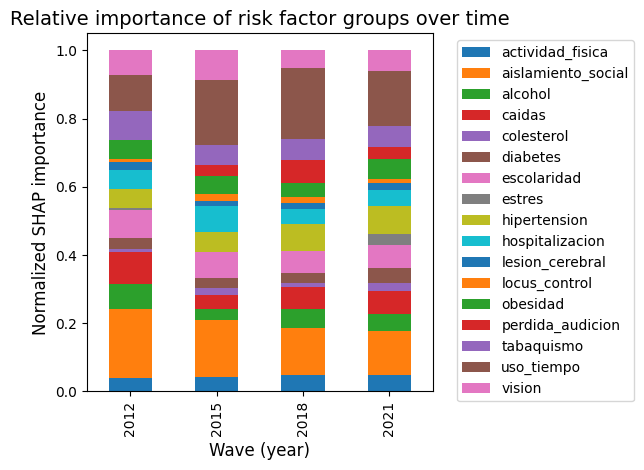

In [ ]:
# --- Inspect results content ---
print("\n🔍 Checking what’s inside `results`:")
for k, v in results.items():
    print(f"Wave {k}: type={type(v)}, length={len(v) if hasattr(v,'__len__') else 'N/A'}")
    if isinstance(v, pd.Series):
        print(f"  Series name dtype: {v.dtype}, first few:\n{v.head(3)}\n")
    else:
        print("  Not a Series or empty entry.\n")

# --- Force all entries to numeric Series ---
clean_results = {}
for wave, imp in results.items():
    if isinstance(imp, pd.Series):
        imp = pd.to_numeric(imp, errors="coerce")
        clean_results[wave] = imp
    else:
        print(f"⚠️ Skipping wave {wave} (non-Series).")

# --- If still empty, abort early ---
if not clean_results:
    raise ValueError("❌ `results` is empty or non-numeric — check earlier SHAP aggregation step!")

# --- Align all waves by index (risk groups) ---
importance_df = pd.DataFrame(clean_results)
importance_df = importance_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# --- Normalize (optional) ---
col_sums = importance_df.sum(axis=0)
if (col_sums == 0).any():
    print("⚠️ Some waves have total SHAP = 0, skipping normalization for those.")
importance_df = importance_df.div(col_sums.replace(0, np.nan), axis=1)

# --- Plot ---
plt.figure(figsize=(12, 6))
importance_df.T.plot(kind="bar", stacked=True)
plt.title("Relative importance of risk factor groups over time", fontsize=14)
plt.ylabel("Normalized SHAP importance", fontsize=12)
plt.xlabel("Wave (year)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Identify Persistent vs. Emerging Predictors

In [ ]:
trend = importance_df.mean(axis=1).sort_values(ascending=False)
print("🔥 Persistent predictors across waves:\n", trend.head(10))

growth = (importance_df.iloc[:, -1] - importance_df.iloc[:, 0]).sort_values(ascending=False)
print("\n📈 Emerging predictors (importance gain):\n", growth.head(10))

🔥 Persistent predictors across waves:
 uso_tiempo            0.166406
aislamiento_social    0.159323
escolaridad           0.072989
hipertension          0.068301
caidas                0.067695
vision                0.067487
tabaquismo            0.066222
hospitalizacion       0.055248
alcohol               0.052298
obesidad              0.051933
dtype: float64

📈 Emerging predictors (importance gain):
 uso_tiempo          0.054984
perdida_audicion    0.030914
estres              0.030292
hipertension        0.024153
diabetes            0.013250
colesterol          0.012671
actividad_fisica    0.007347
obesidad            0.007011
locus_control       0.000975
lesion_cerebral    -0.003454
dtype: float64


Visualize SHAP Summaries per Wave

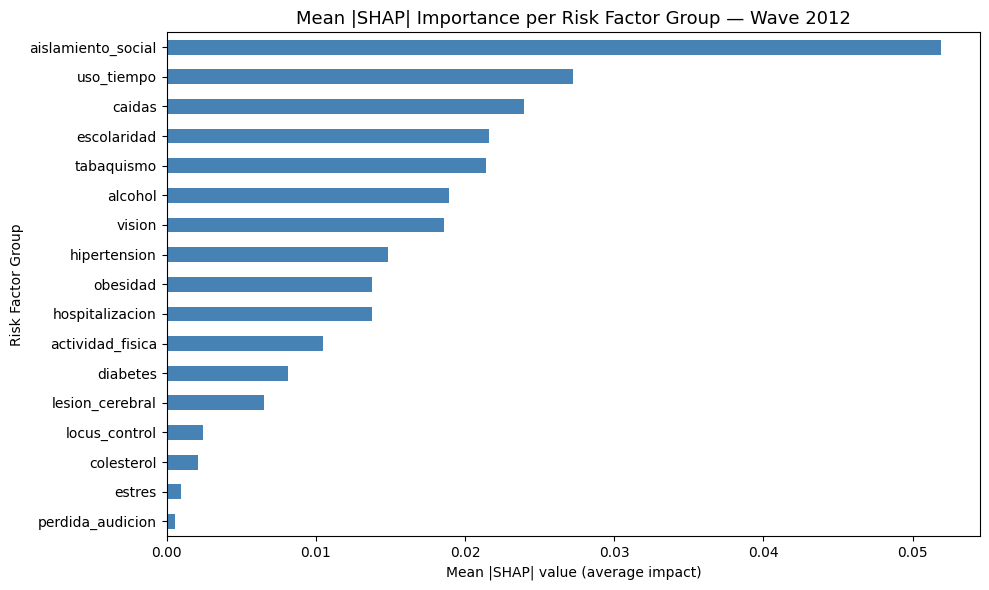

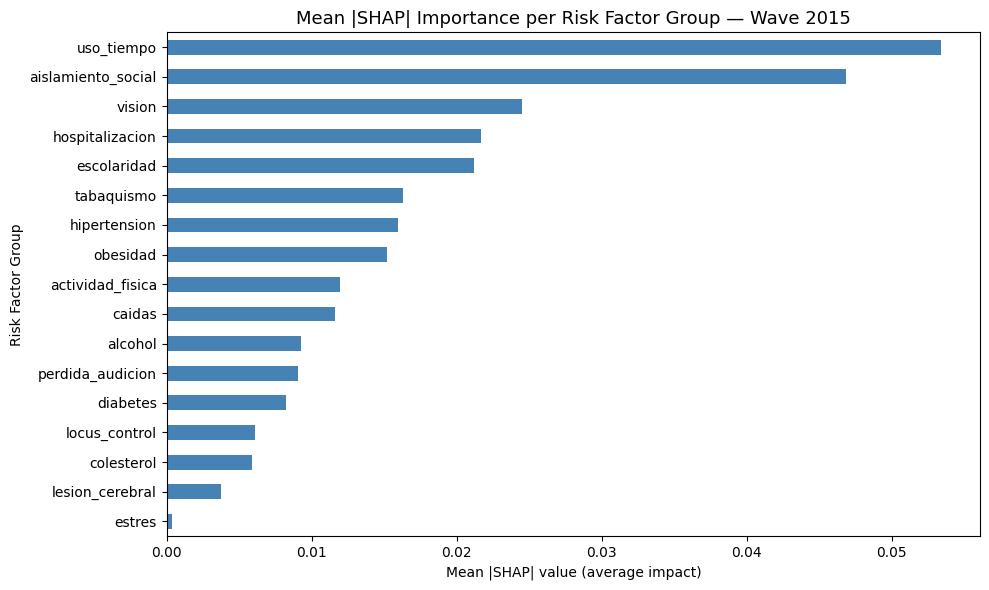

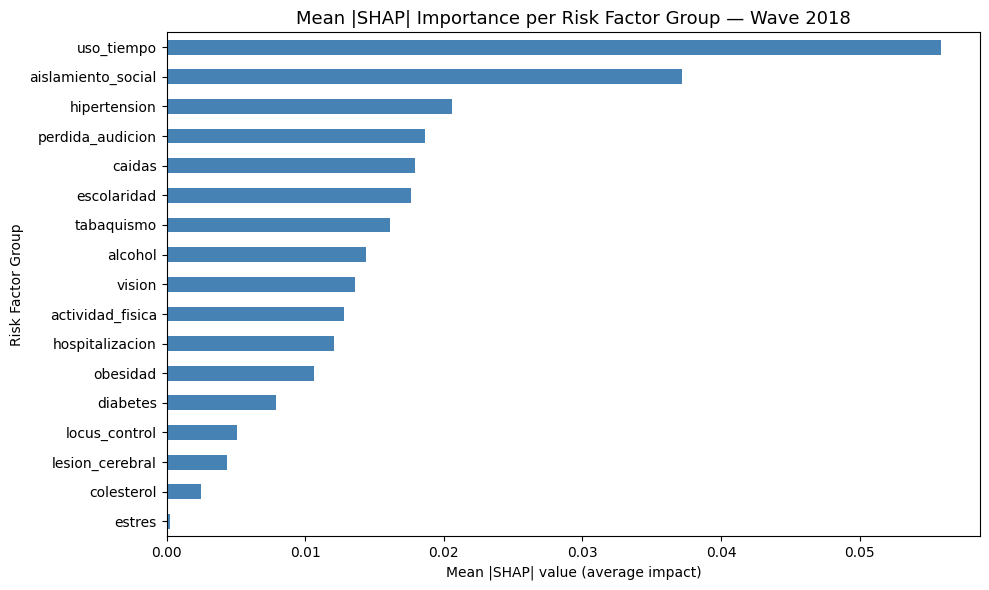

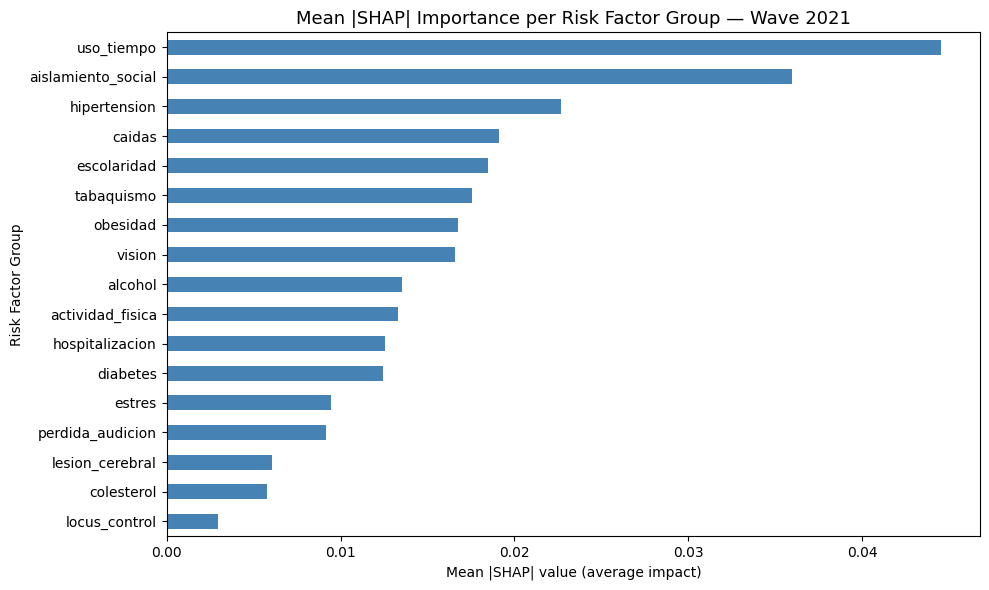

In [ ]:
for wave, shap_series in sorted(results.items()):
    plt.figure(figsize=(10, 6))
    shap_series.sort_values(ascending=True).plot(kind="barh", color="steelblue")
    plt.title(f"Mean |SHAP| Importance per Risk Factor Group — Wave {wave}", fontsize=13)
    plt.xlabel("Mean |SHAP| value (average impact)")
    plt.ylabel("Risk Factor Group")
    plt.tight_layout()
    plt.show()

SHAP Importance Evolution

/tmp/ipython-input-4088803456.py:18: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


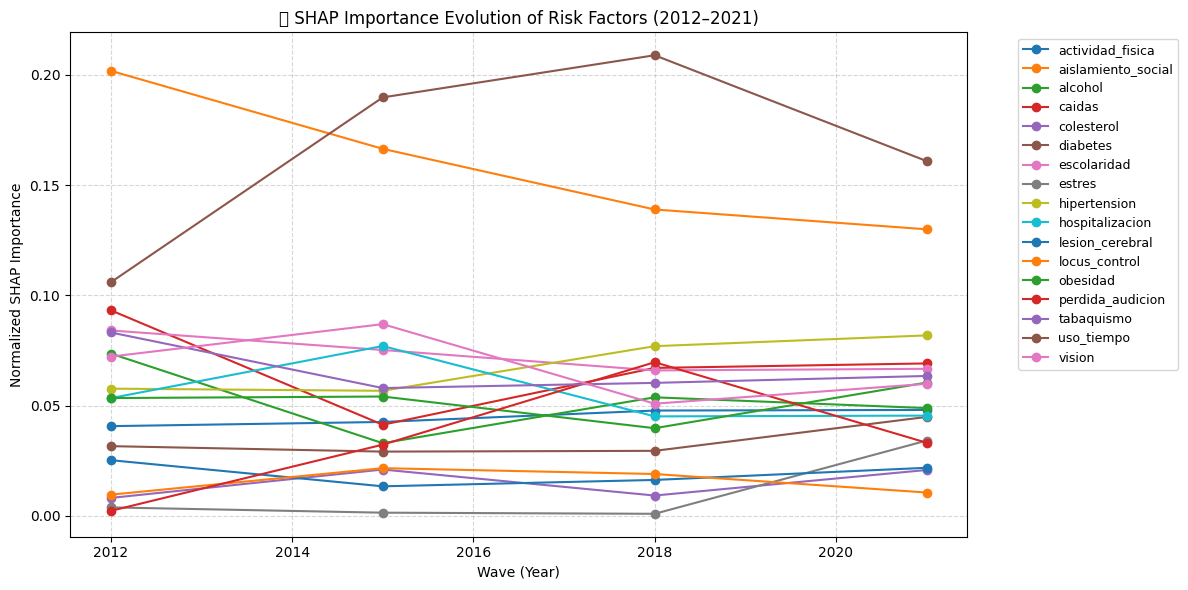

In [ ]:
# Load results
results = joblib.load("saved_results/all_wave_results.joblib")
importance_df = pd.DataFrame(results).fillna(0)

# Normalize within each wave
importance_df = importance_df.div(importance_df.sum(axis=0), axis=1)

# Plot over time
plt.figure(figsize=(12,6))
for factor in importance_df.index:
    plt.plot(importance_df.columns, importance_df.loc[factor], marker='o', label=factor)

plt.title("📈 SHAP Importance Evolution of Risk Factors (2012–2021)")
plt.xlabel("Wave (Year)")
plt.ylabel("Normalized SHAP Importance")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", fontsize=9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Quantify Trends Between Waves

In [ ]:
# Calculate change between consecutive waves
diffs = importance_df.diff(axis=1).iloc[:, 1:]  # skip first column (NaN diff)

print("📉 Change in SHAP importance between waves:")
display(diffs)

# Mean trend across all intervals (slope over time)
trend = diffs.mean(axis=1).sort_values(ascending=False)
print("\n📈 Average SHAP Importance Change per 3-Year Interval:")
display(trend)


📉 Change in SHAP importance between waves:


,2015,2018,2021
actividad_fisica,0.001903,0.005177,0.000268
aislamiento_social,-0.035390,-0.027512,-0.008985
alcohol,-0.040660,0.020813,-0.004889
caidas,-0.051914,0.025775,0.002040
colesterol,0.012884,-0.011799,0.011586
diabetes,-0.002478,0.000347,0.015380
escolaridad,-0.008863,-0.009270,0.000741
estres,-0.002396,-0.000505,0.033193
hipertension,-0.000978,0.020246,0.004885
hospitalizacion,0.023632,-0.031917,0.000355



📈 Average SHAP Importance Change per 3-Year Interval:


,0
uso_tiempo,0.018328
perdida_audicion,0.010305
estres,0.010097
hipertension,0.008051
diabetes,0.004417
colesterol,0.004224
actividad_fisica,0.002449
obesidad,0.002337
locus_control,0.000325
lesion_cerebral,-0.001151


Change Dynamics Heatmap

/tmp/ipython-input-1520240408.py:6: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


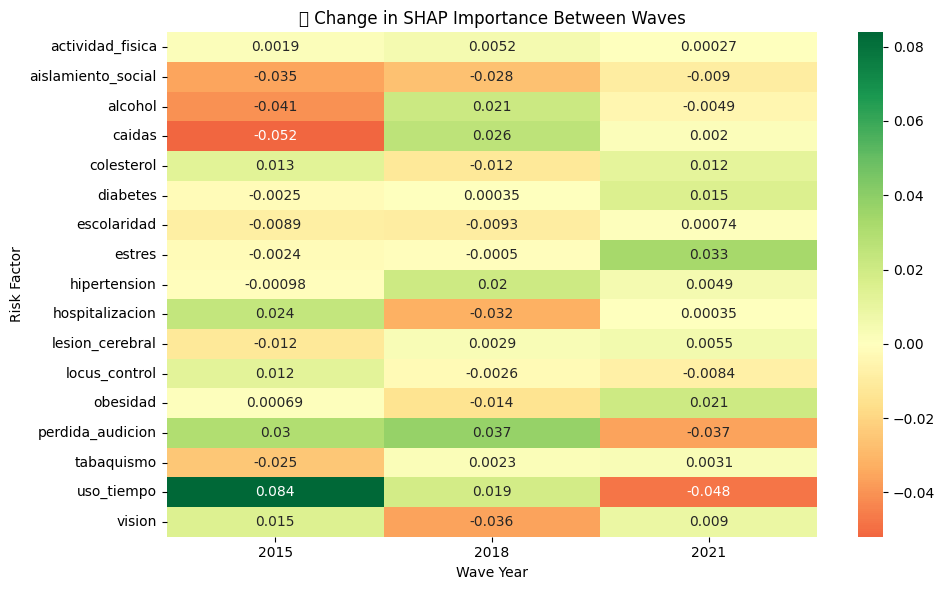

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(diffs, annot=True, cmap="RdYlGn", center=0)
plt.title("🔄 Change in SHAP Importance Between Waves")
plt.xlabel("Wave Year")
plt.ylabel("Risk Factor")
plt.tight_layout()
plt.show()

Correlation of SHAP with time

In [ ]:
# Convert wave columns to numeric years
years = pd.to_numeric(importance_df.columns)

# Compute correlation between each risk factor’s SHAP series and year progression
corr_with_time = importance_df.apply(
    lambda row: row.corr(pd.Series(years, index=importance_df.columns)),
    axis=1
).sort_values(ascending=False)

print("📈 Correlation of SHAP Importance with Time (2012→2021):")
display(corr_with_time)

📈 Correlation of SHAP Importance with Time (2012→2021):


,0
lesion_cerebral,0.956415
diabetes,0.876419
estres,0.855880
caidas,0.849266
perdida_audicion,0.724814
vision,0.348575
tabaquismo,-0.006829
hipertension,-0.054908
locus_control,-0.145832
escolaridad,-0.207028
